Tracking of blood test results and more

Resources:
- https://github.com/markwk/awesome-biomarkers
- https://docs.google.com/spreadsheets/d/1WVhjSNUQh4xuc41cLuChE-DthZzEemHxeHghbCdQ2sA/edit?usp=sharing






## PhenoAge

Derived from calculator at  https://www.drkarafitzgerald.com/younger-you-phenoage/
Using my laboratory test results in file "blutbild.csv"

In [2]:
from datetime import date
import csv
import math


biomarkers_data = 'blutbild.csv'
birthday = date(1969,12,13)
column = '2023-01-09'


def read_csv_cell(row_name, column_name=column,filename=biomarkers_data):
    with open(filename, 'r', newline='') as file:
        reader = csv.DictReader(file)
        for row in reader:
            if row['Wert'] == row_name:
                if row[column_name] != '':
                    return row[column_name]
                else:
                    #if no value found, look for previous entries
                    columns = list(row.keys())[4:]
                    columns.reverse()
                    for col in columns:
                        if col == 'Normalwert':
                            return None
                        if row[col] != '':
                            return row[col]
    return None


def phenoAge( column_name=column ):
    albumin = float(read_csv_cell('Albumin abs.')) * -0.0336
    creatinine = float(read_csv_cell('Kreatinin')) * 88.4 *  0.0095
    glucose = float(read_csv_cell('Glukose / Blutzucker')) * 0.0555 * 0.1953
    CRP = math.log(float(read_csv_cell('C-reaktives Protein (hs)')) * 0.1, math.e) * 0.0954
    Lympocyte = float(read_csv_cell('Lymphozyten')) * -0.012
    MeanCellVolume = float(read_csv_cell('MCV')) * 0.0268
    RedCellDistWidth = float(read_csv_cell('Ery. Verteilungsbreite (RDW)')) * 0.3306
    AlkalinePhosphatase = float(read_csv_cell('Alkalische Phosphatase')) * 0.0019
    #WhiteBloodCells = float(read_csv_cell('Erythrozyten')) * 0.0554
    WBC = float(read_csv_cell('Leukozyten')) * 0.0953
    Age = ( date.today() - birthday ).days / 365.25 * 0.0804
    
    t_years = 10
    t_months = 120
    gamma = 0.00769
    b0 = -19.9067

    #LinComb = albumin + creatinine + glucose + CRP + Lympocyte + MeanCellVolume  + RedCellDistWidth  + AlkalinePhosphatase + WhiteBloodCells + Age + b0
    LinComb = albumin + creatinine + glucose + CRP + Lympocyte + MeanCellVolume  + RedCellDistWidth  + AlkalinePhosphatase + WBC + Age + b0
    MortScore = 1 - math.exp( - math.exp(LinComb) * ( math.exp(gamma * t_months) - 1 ) / gamma)
    PtypicAge = 141.50225 + math.log( -0.00553 * math.log( 1 - MortScore, math.e ), math.e ) / 0.09165
    estDNAmAge = PtypicAge / ( 1 + 1.28047 * math.exp(0.0344329 * (-182.344 + PtypicAge)))
    estD_MScore = 1 - math.exp( -0.000520363523 * math.exp( 0.090165 * estDNAmAge ))
    
    return estDNAmAge

print(f"physical age: {( date.today() - birthday ).days / 365.25 }")
print(f"phenoAge: {phenoAge()}")


physical age: 55.94250513347023
phenoAge: 47.839865283902306


# Biomarker laborartory tests

In [4]:
%pip install pandas
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/17/91/febbb6c1063ae05a62fdbe038c2917b348b1b35f0482cee4738e6870a44a/matplotlib-3.9.0-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/78/38/a046bb0ebce6f530175d434e7364149e338ffe1069ee286ed8ba7f6481ee/contourpy-1.2.1-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.22.0 from https://files.pythonhosted.org/packages/79/3e/3d87230c46a103ae225d47ae59ac6cdbd4fa341dddaffdfaf4e89986dd88/fonttools-4.53.0-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/165.5 kB ? eta -:--:--
     -------------- ------------------------ 61.4/165.5 kB 1.7 MB/s e

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


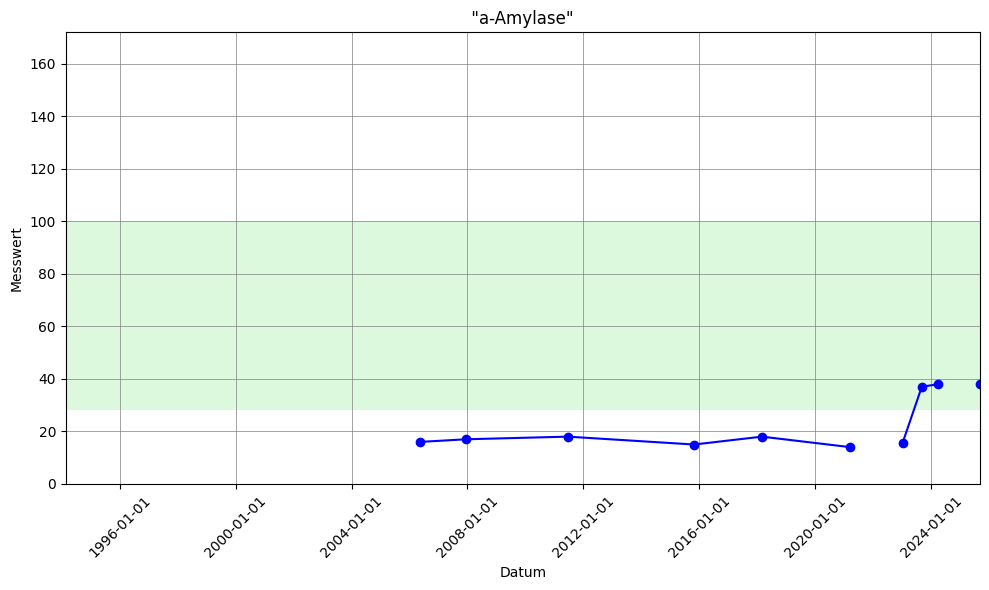

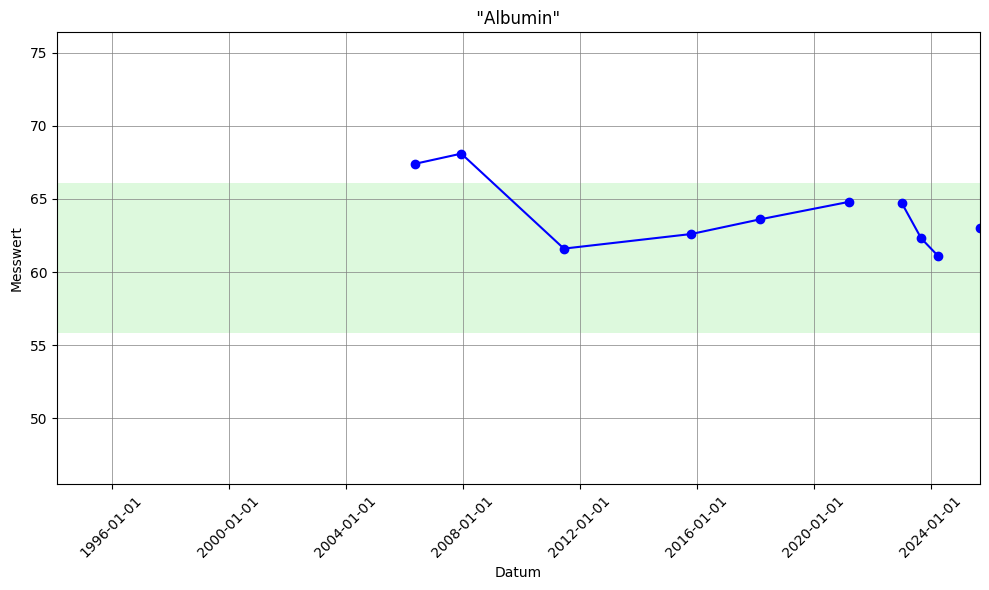

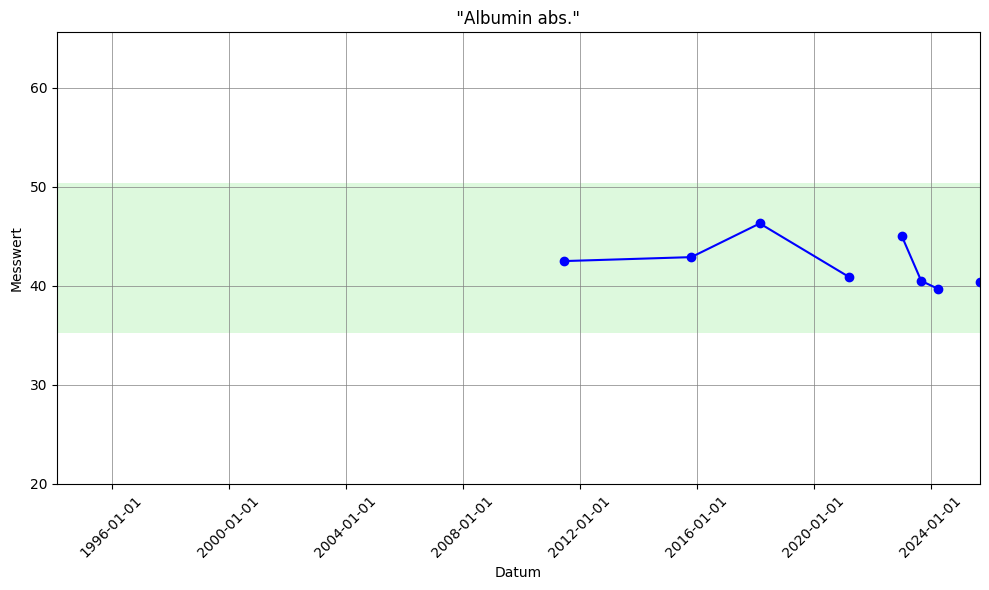

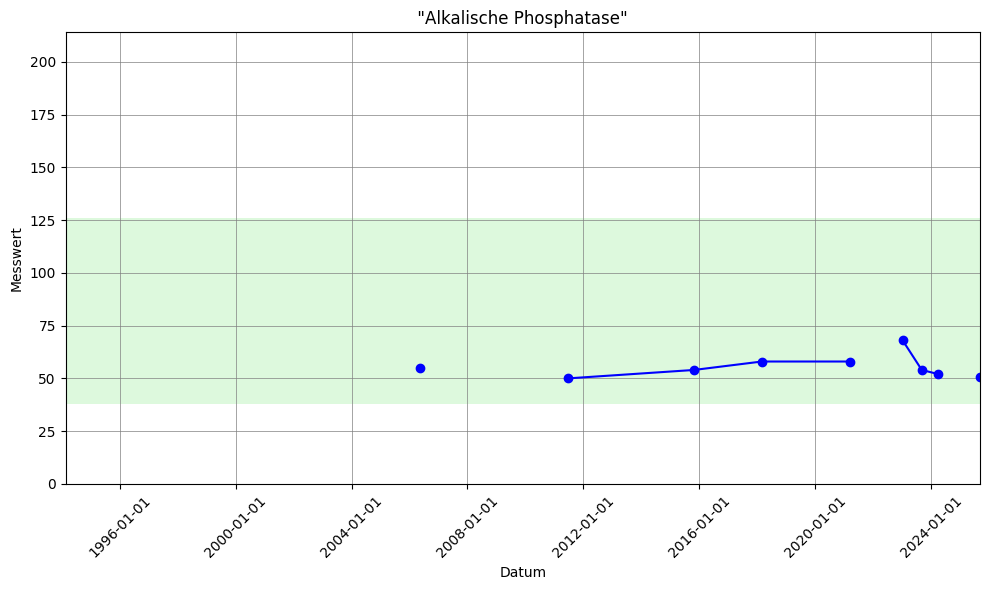

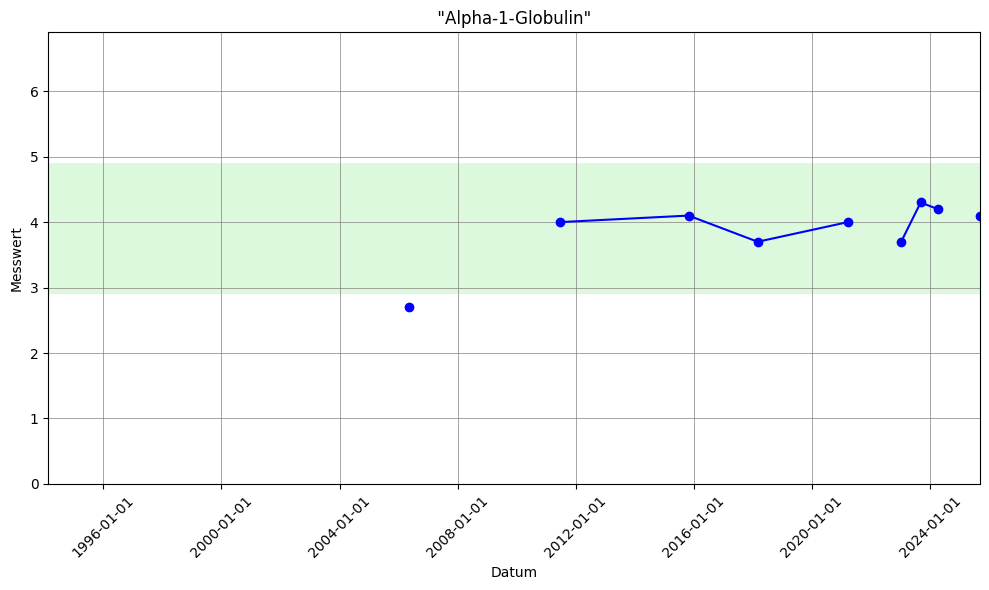

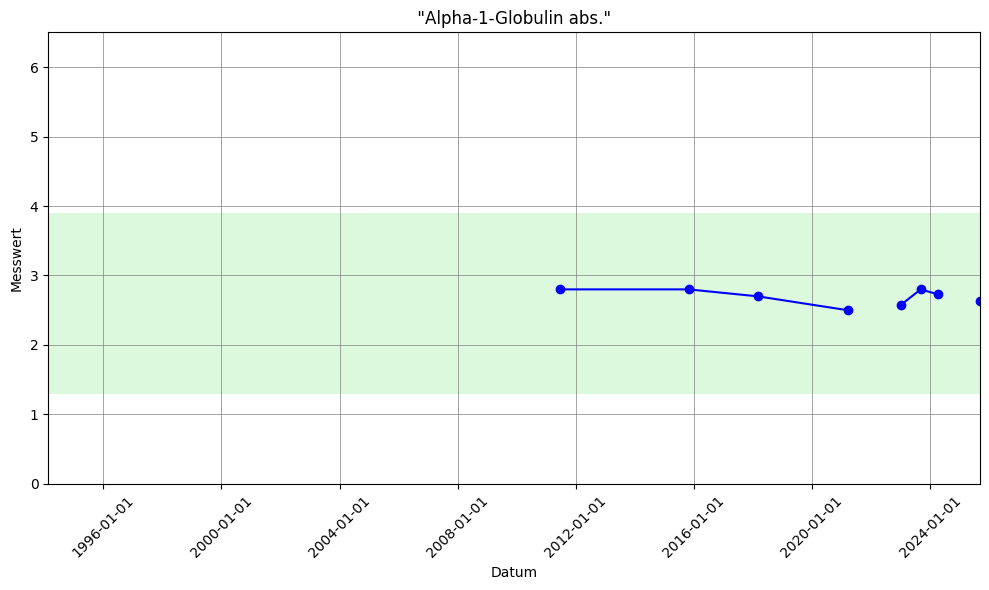

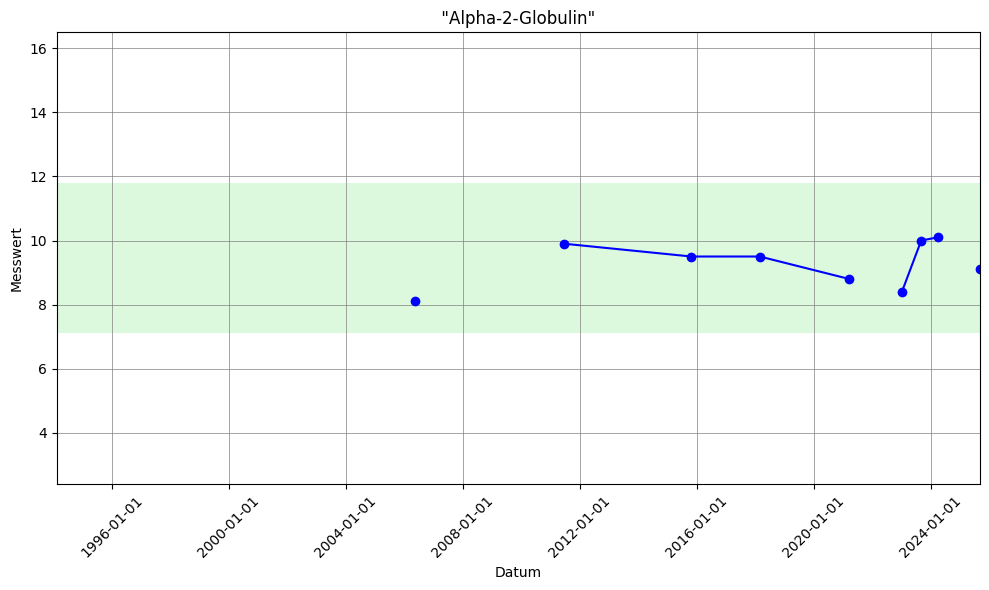

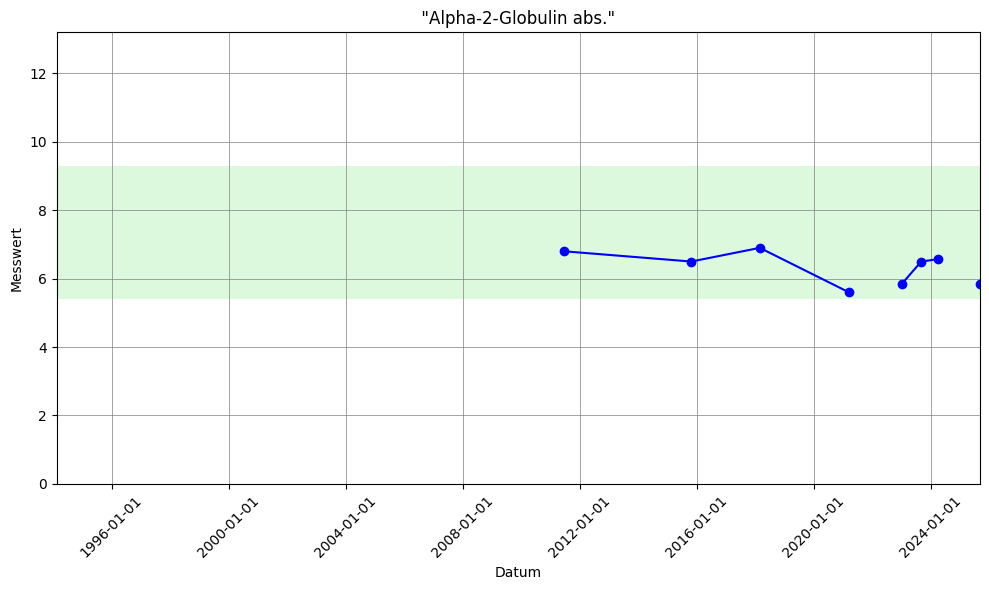

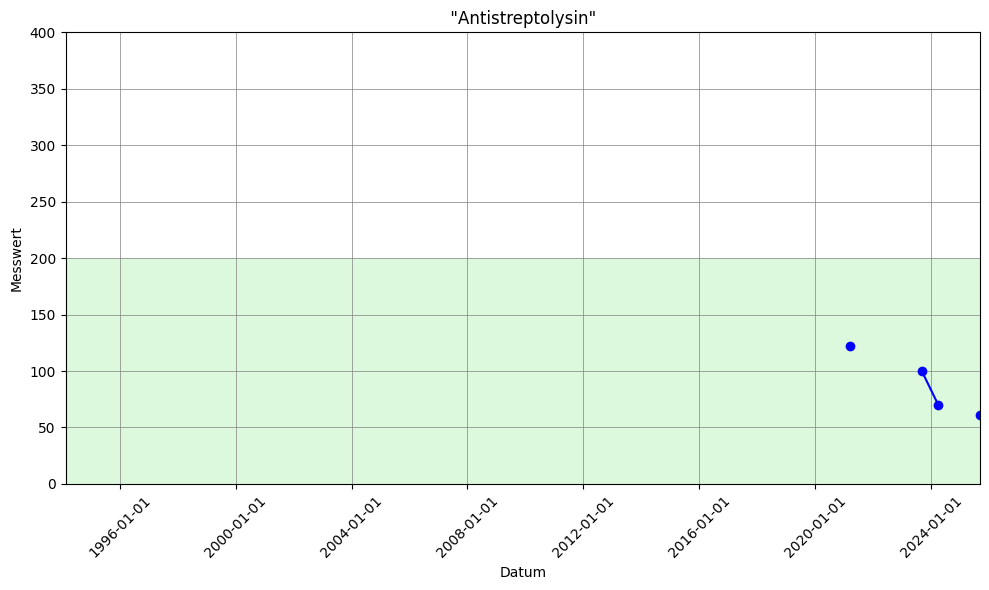

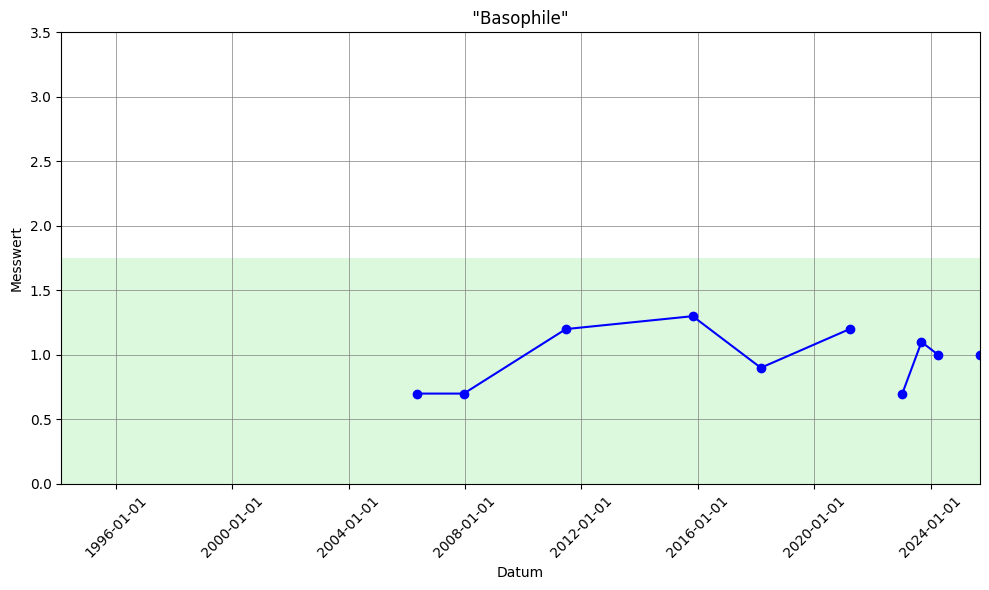

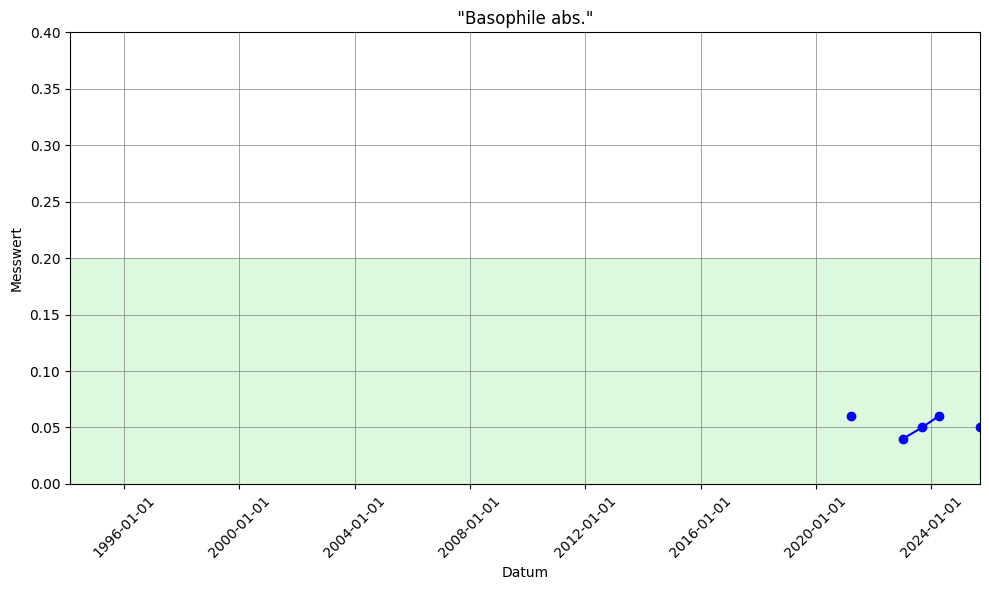

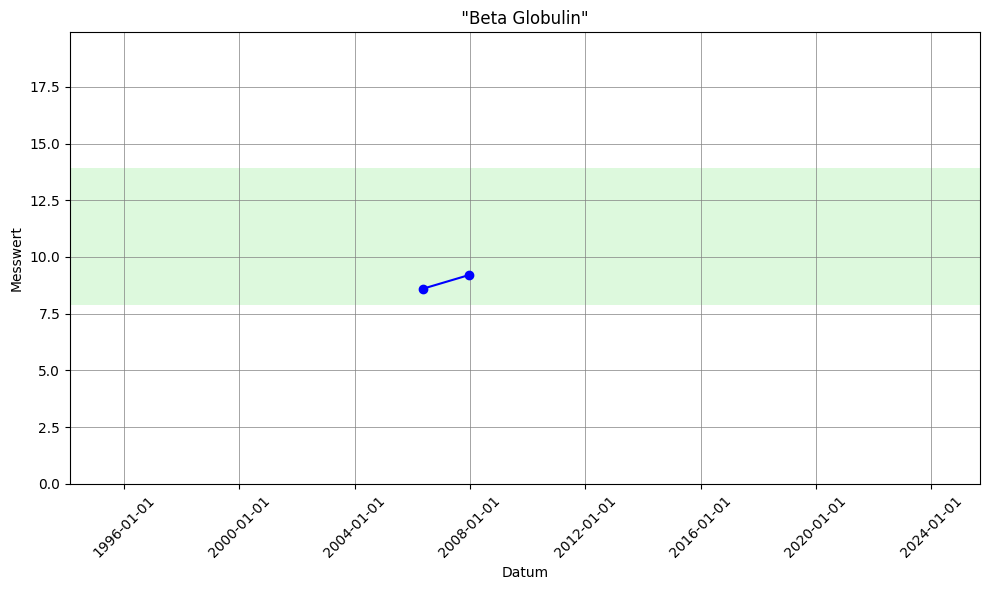

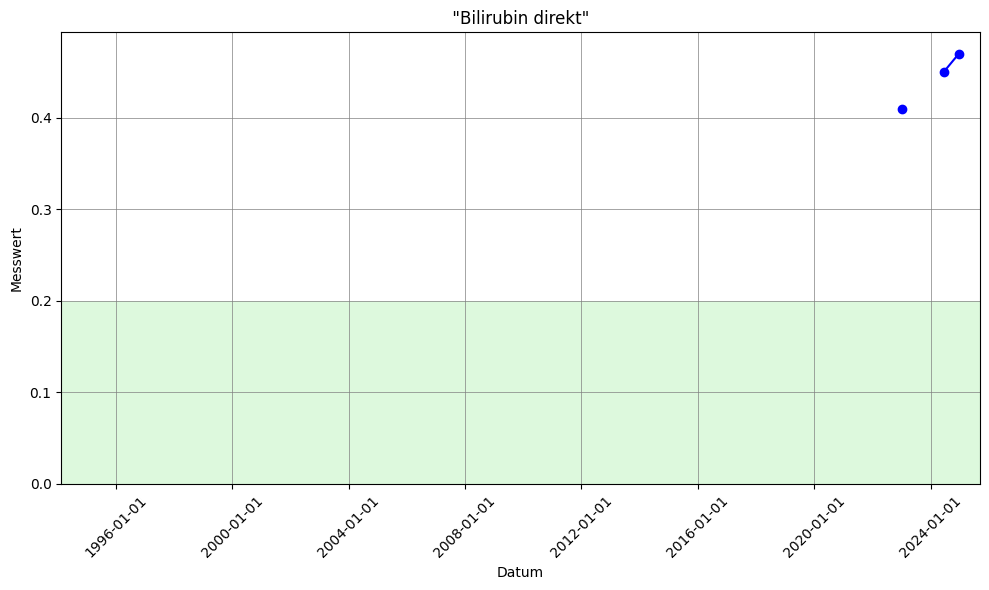

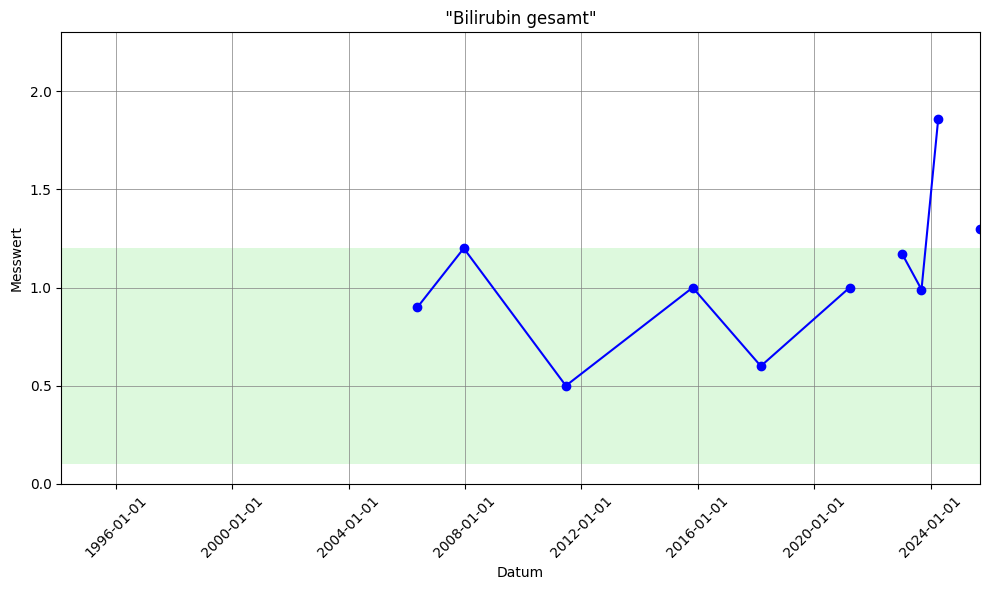

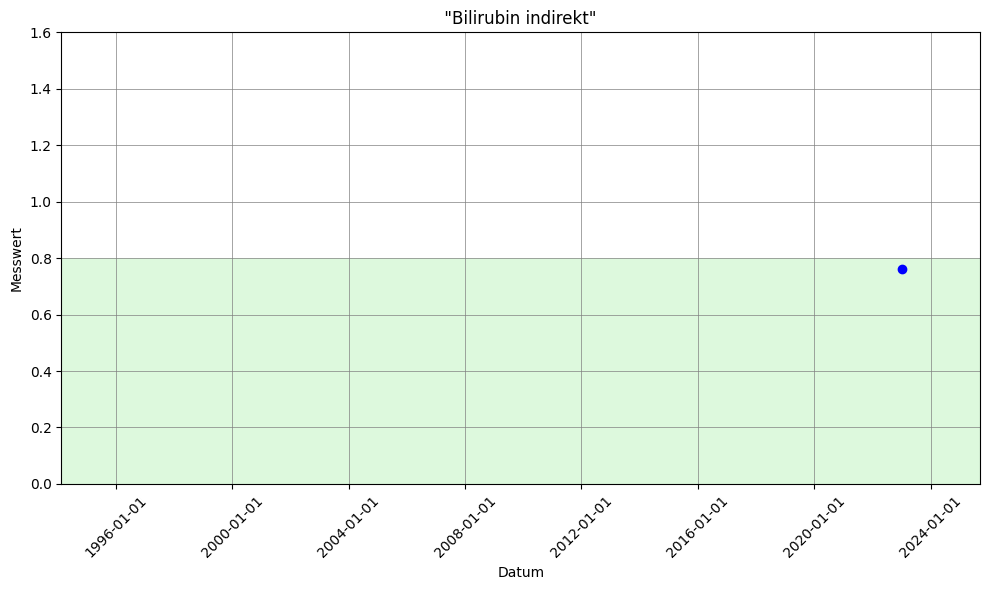

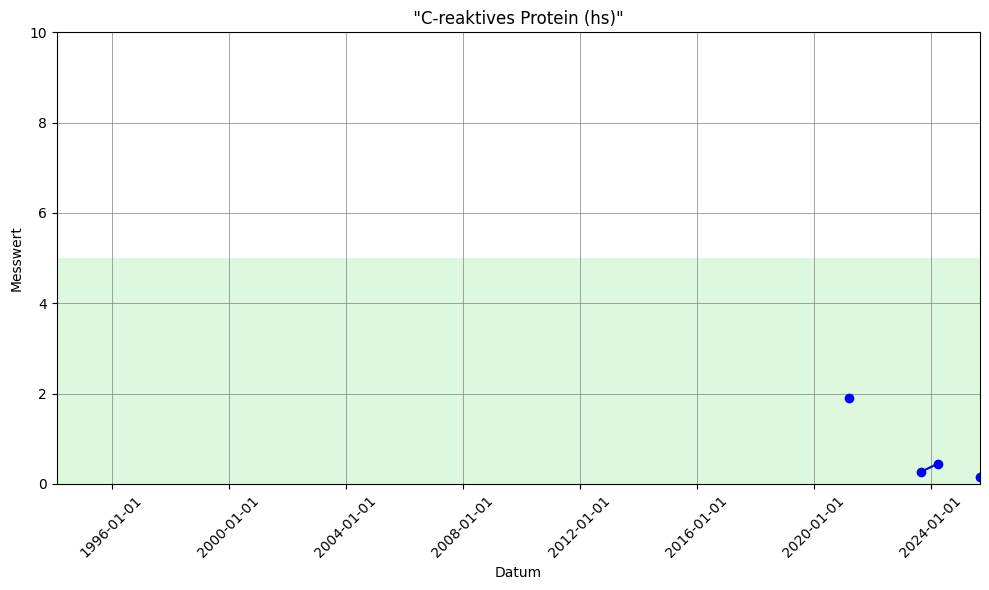

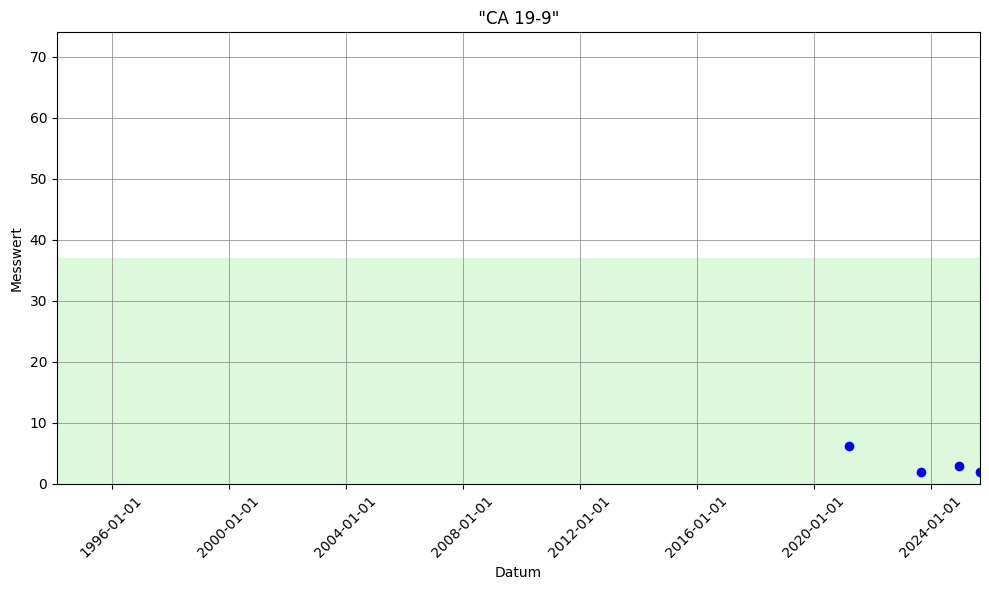

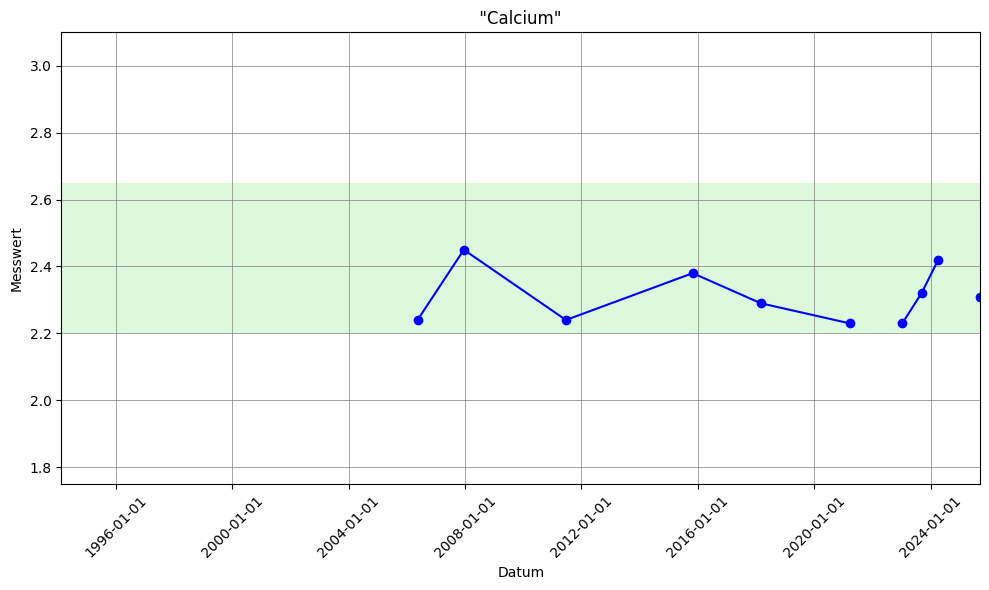

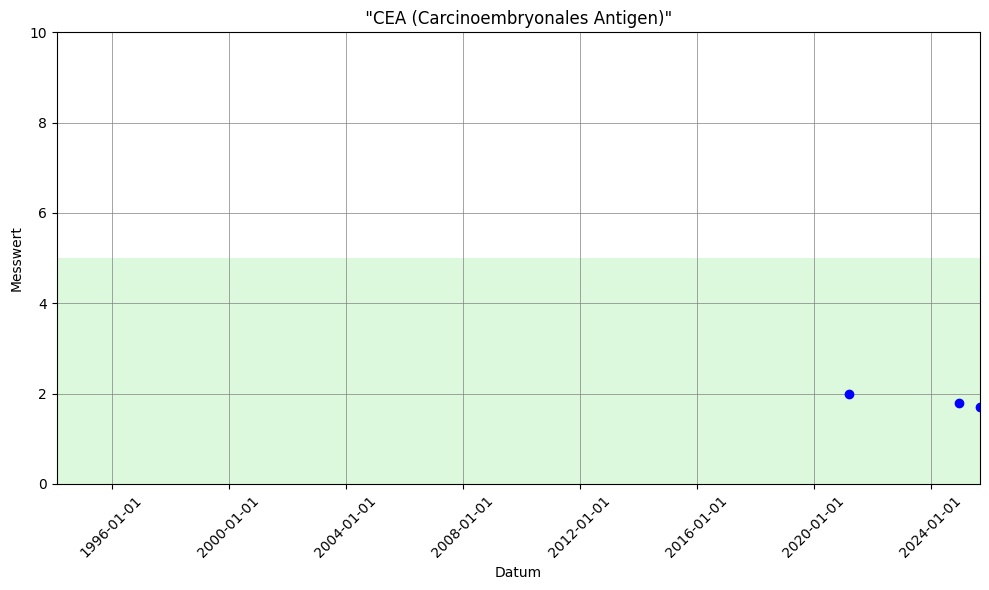

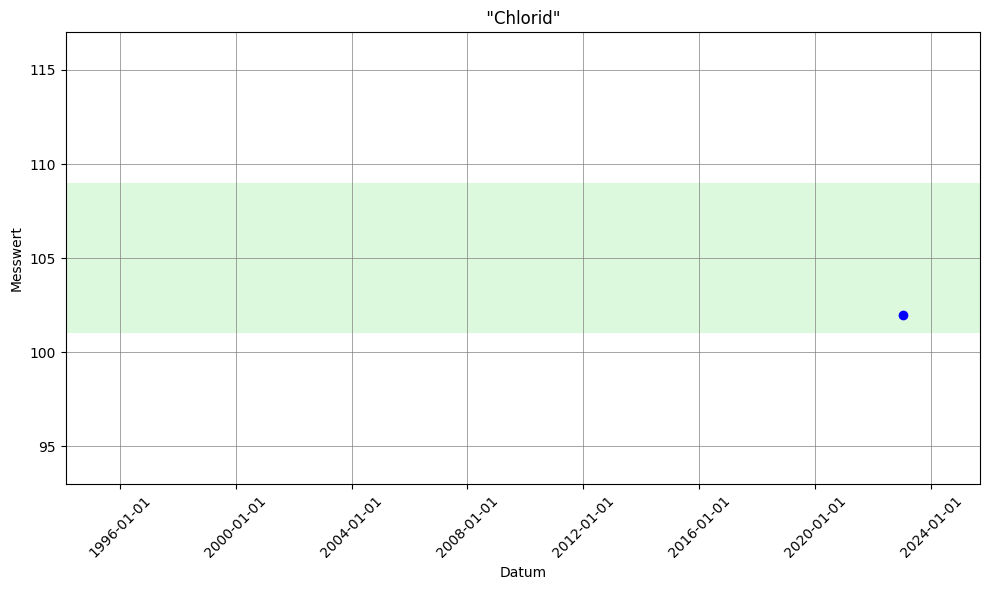

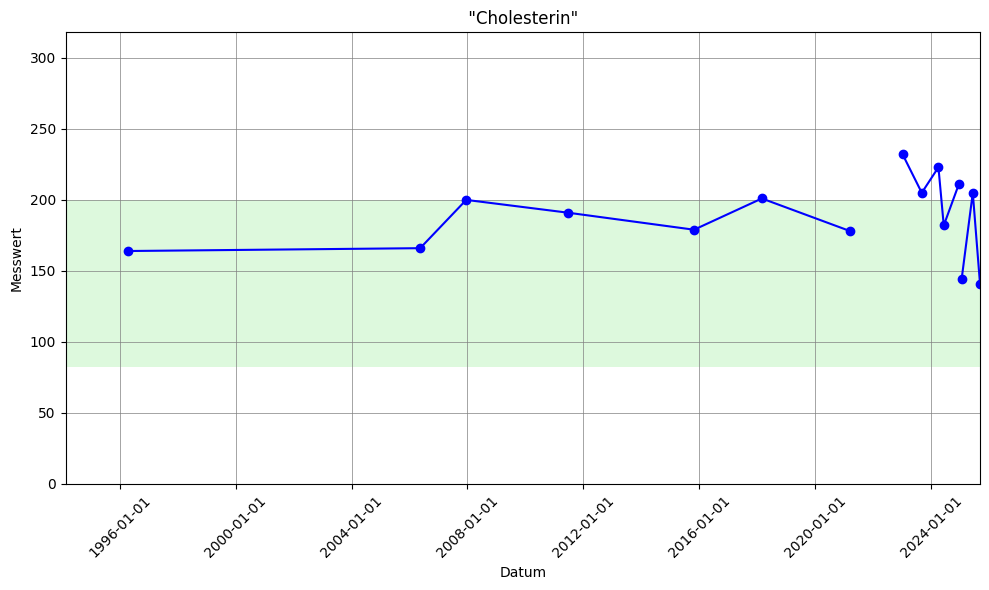

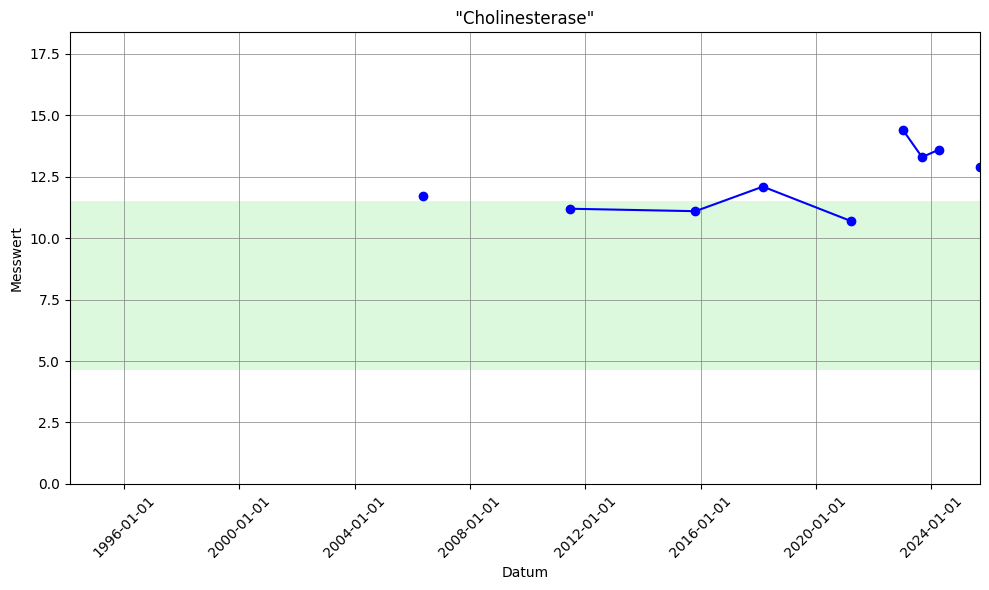

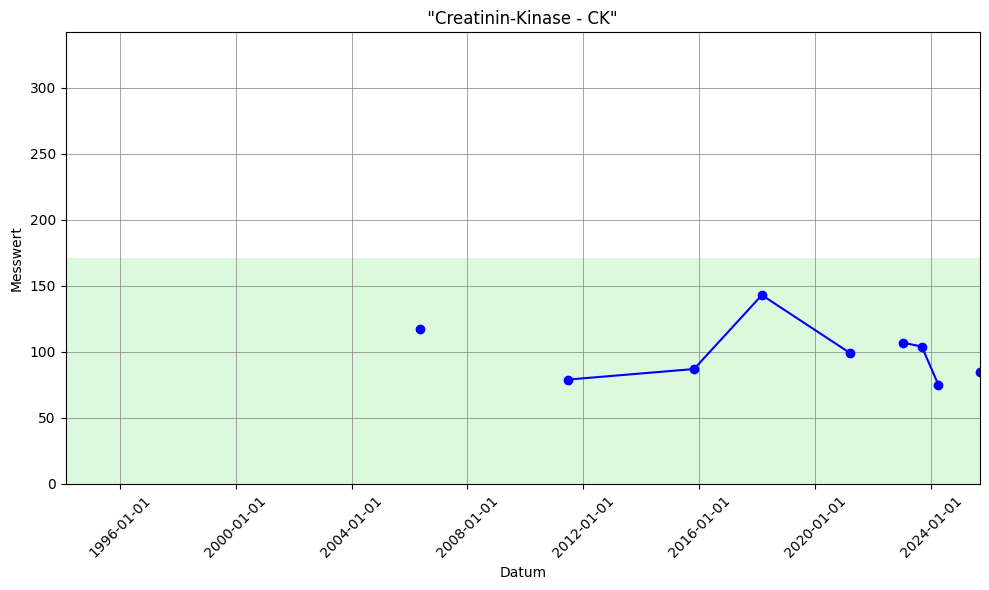

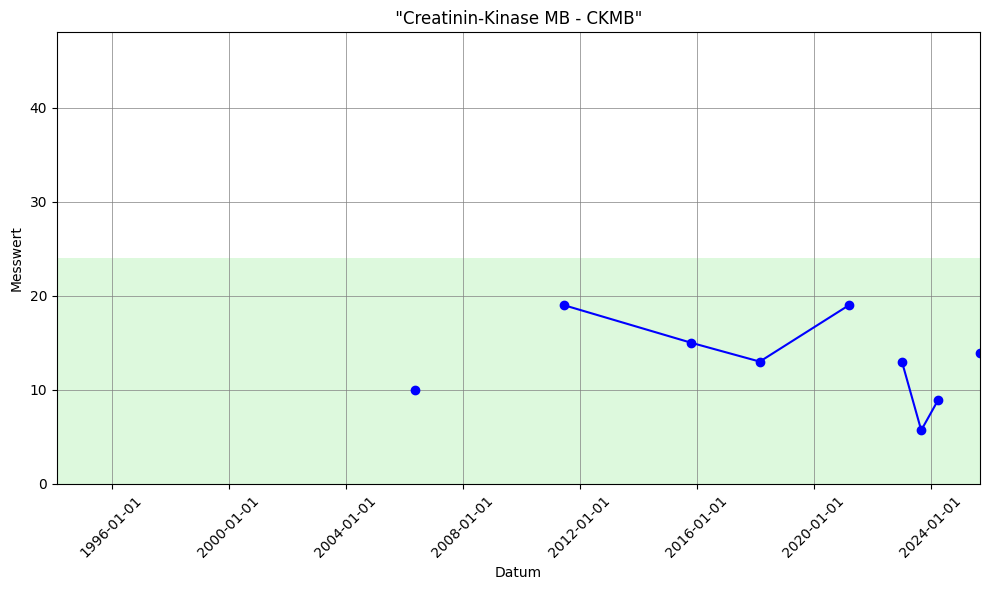

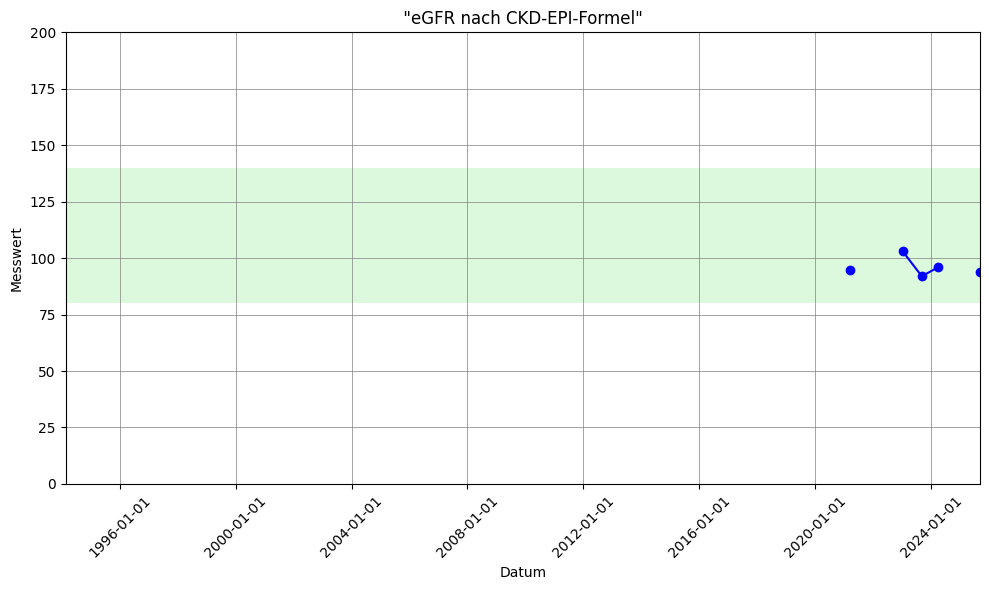

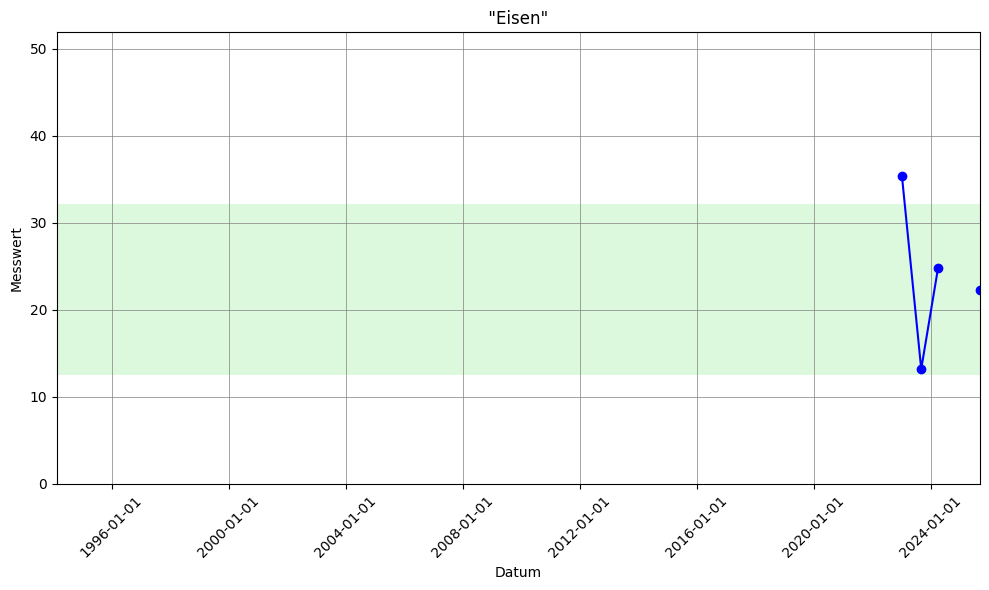

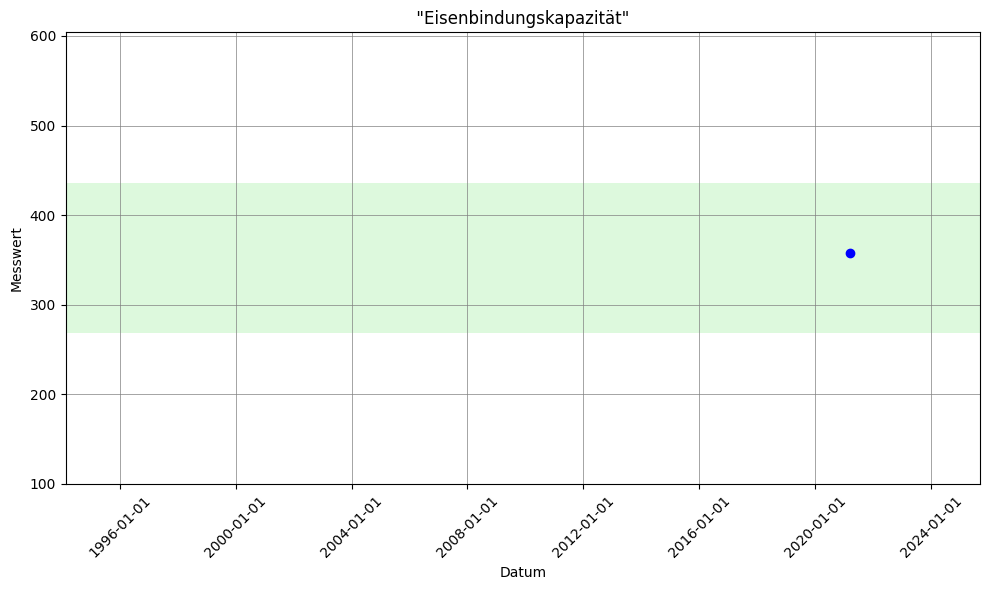

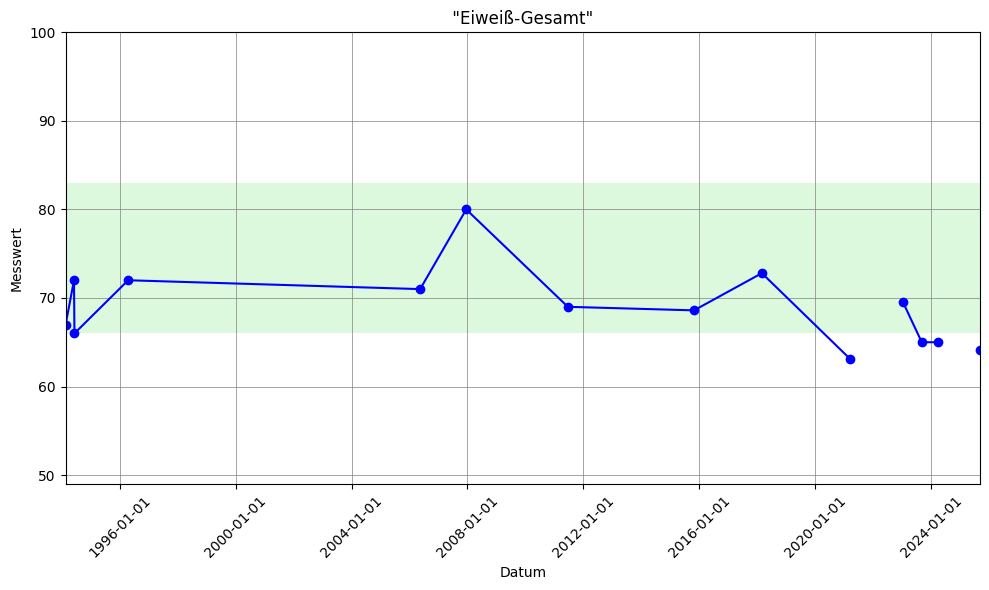

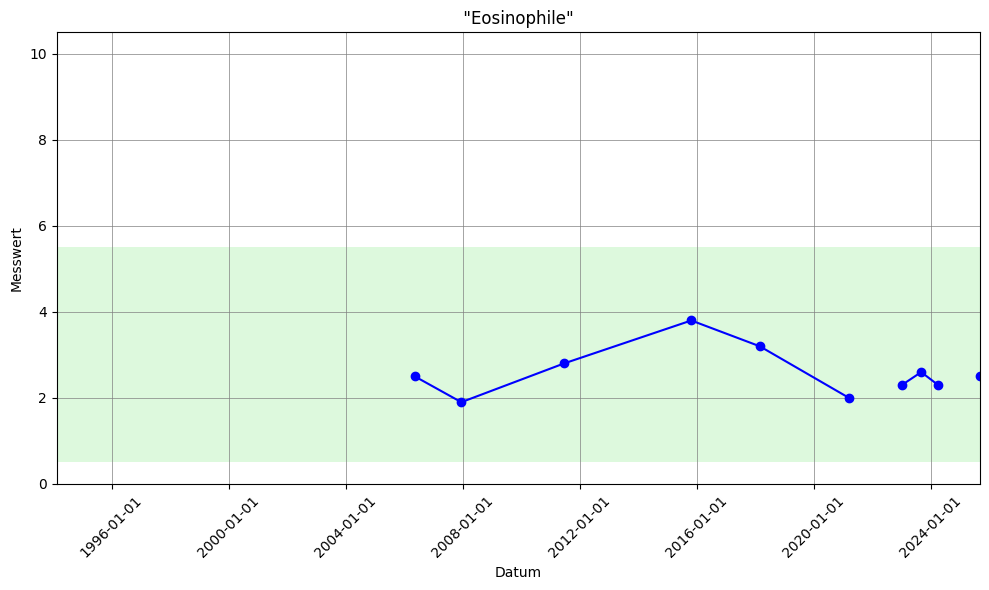

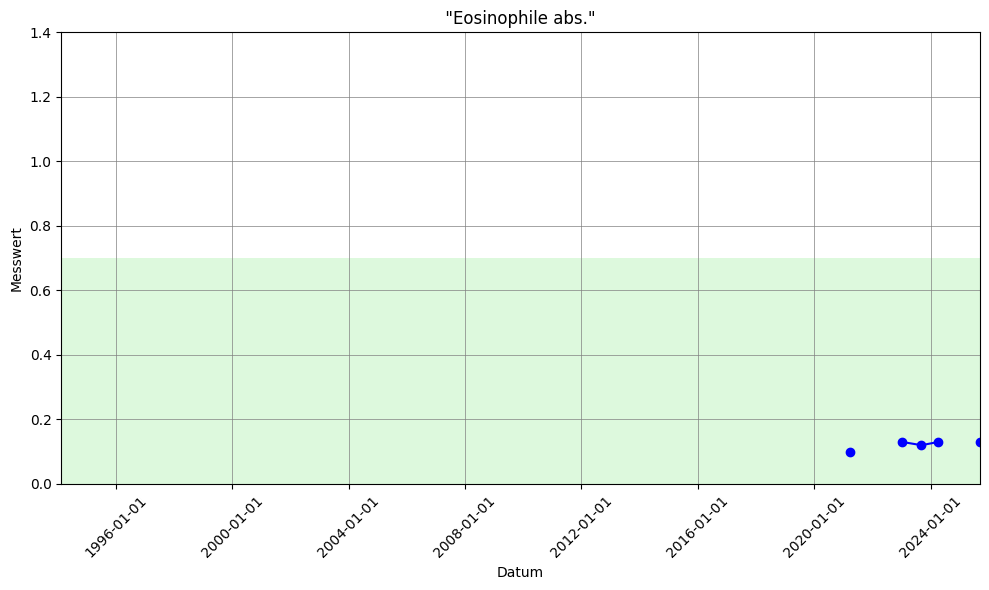

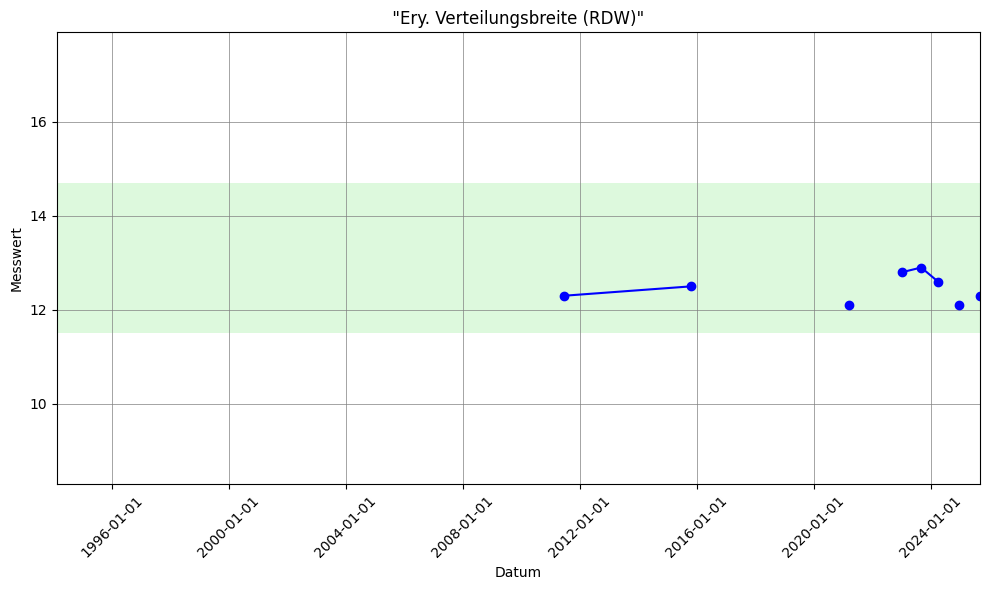

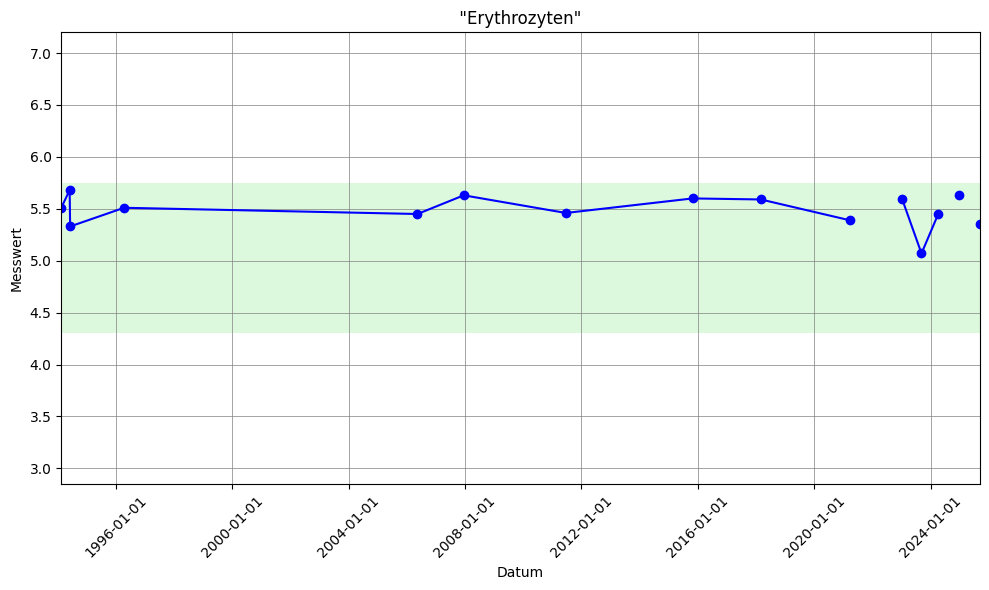

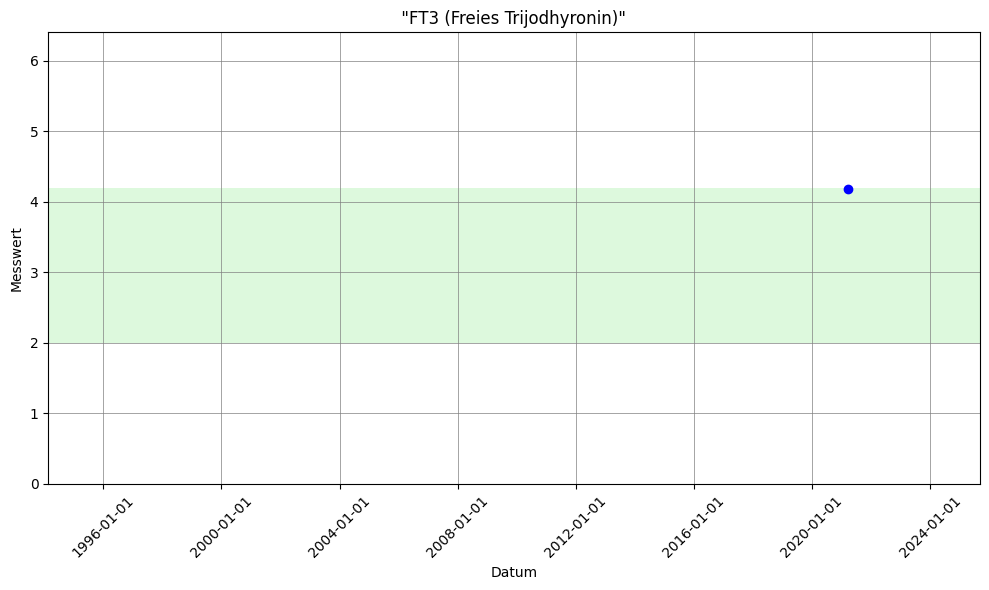

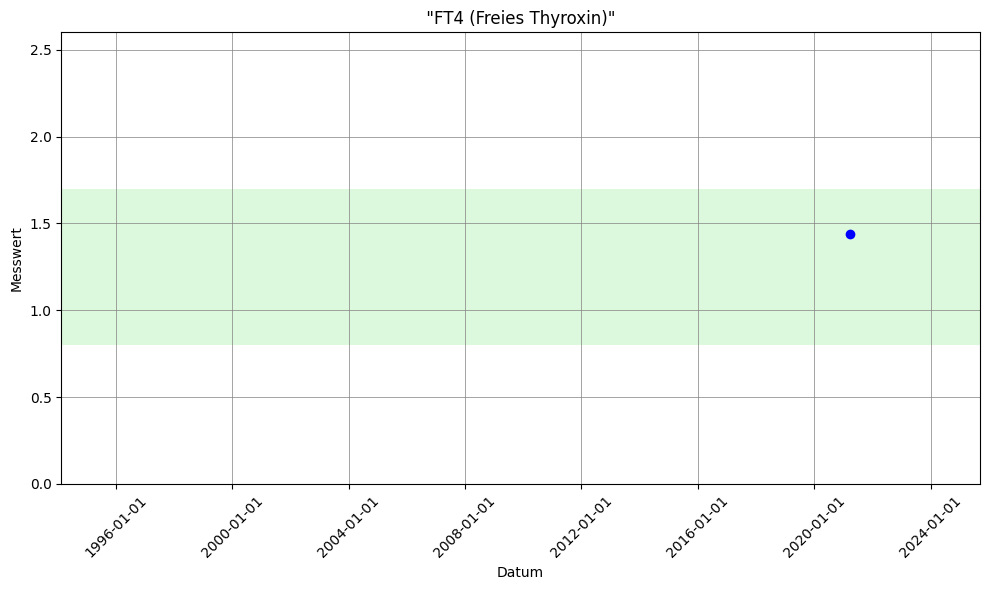

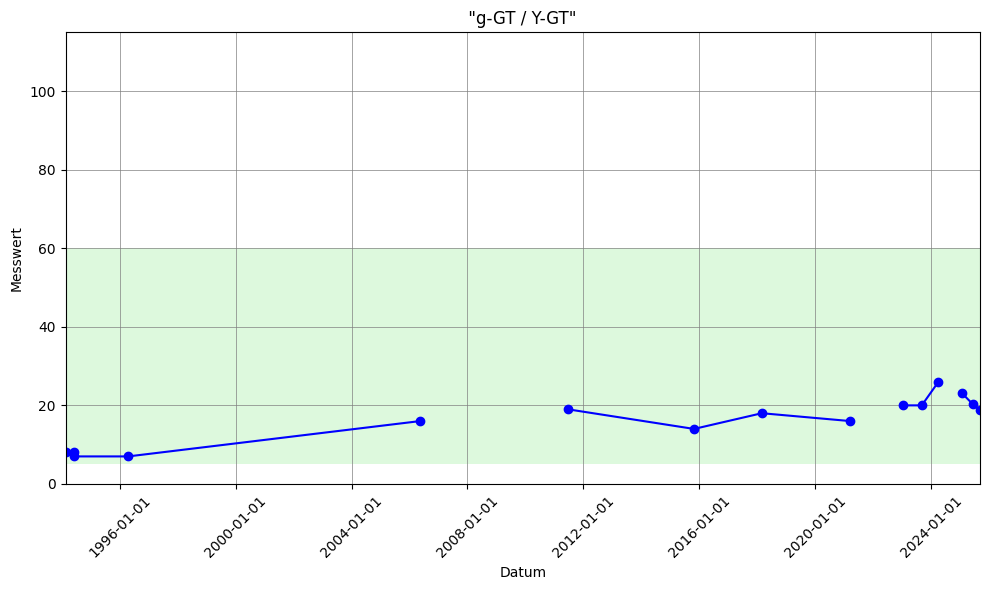

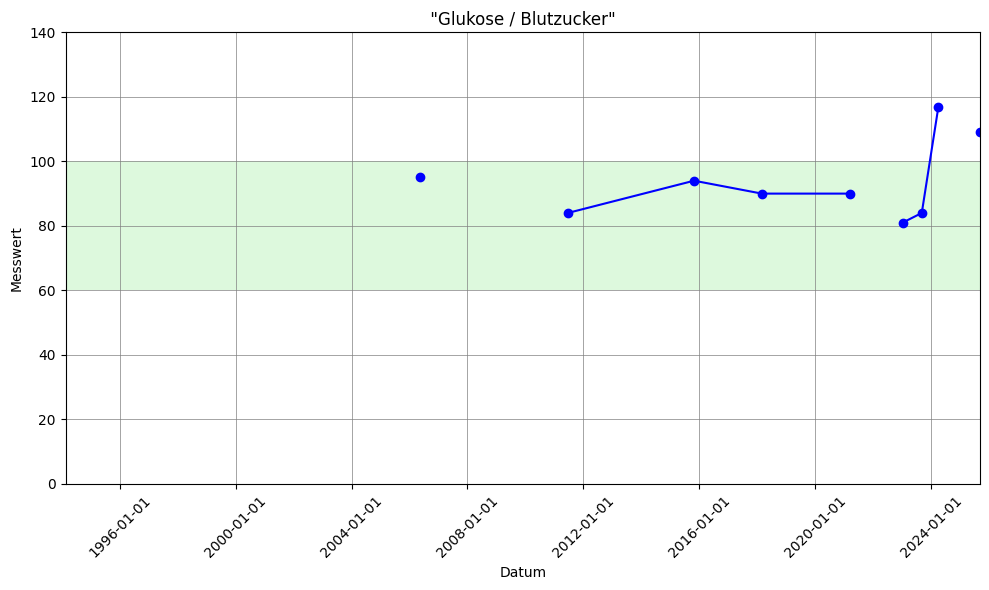

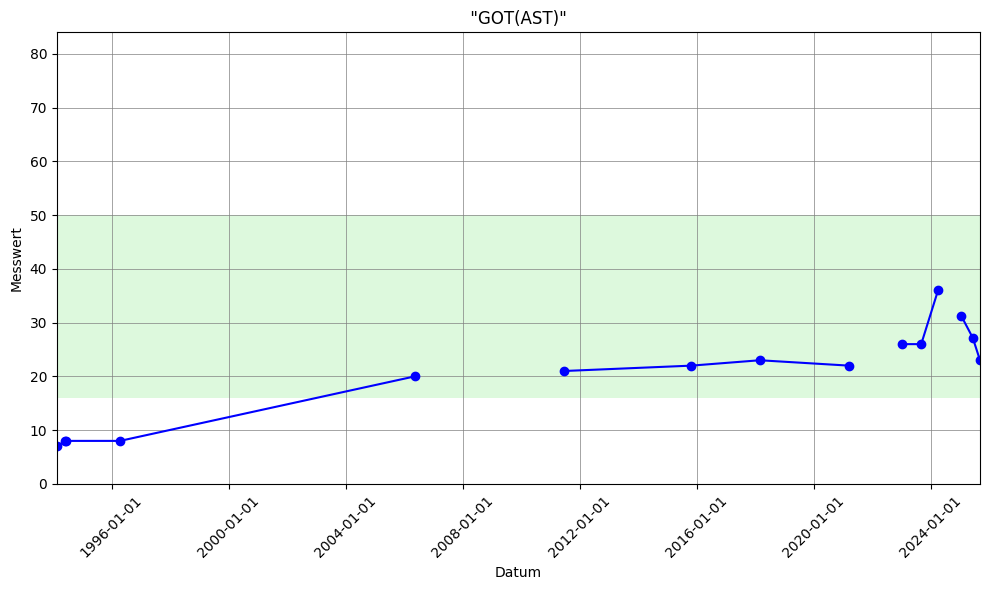

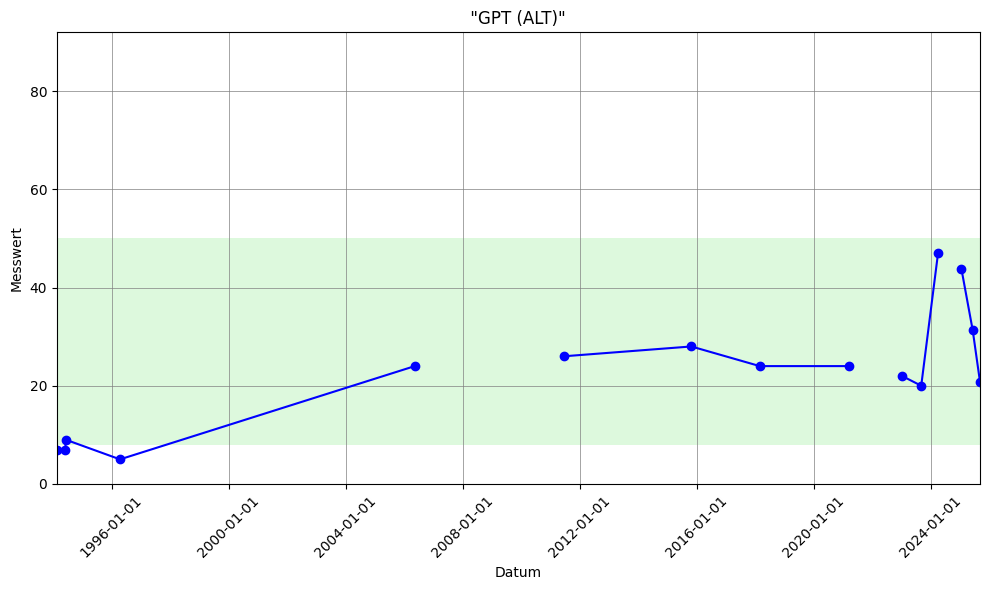

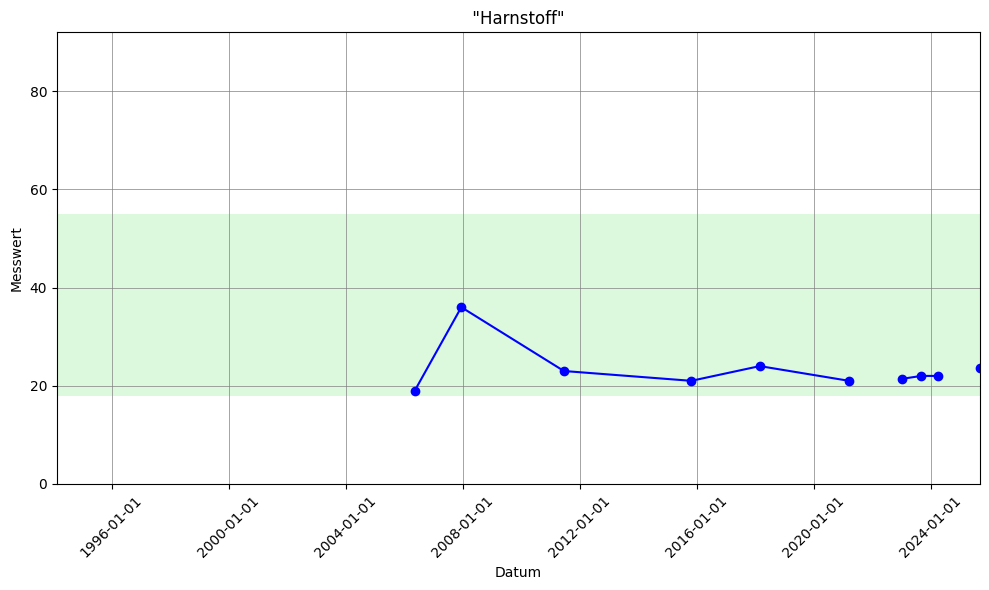

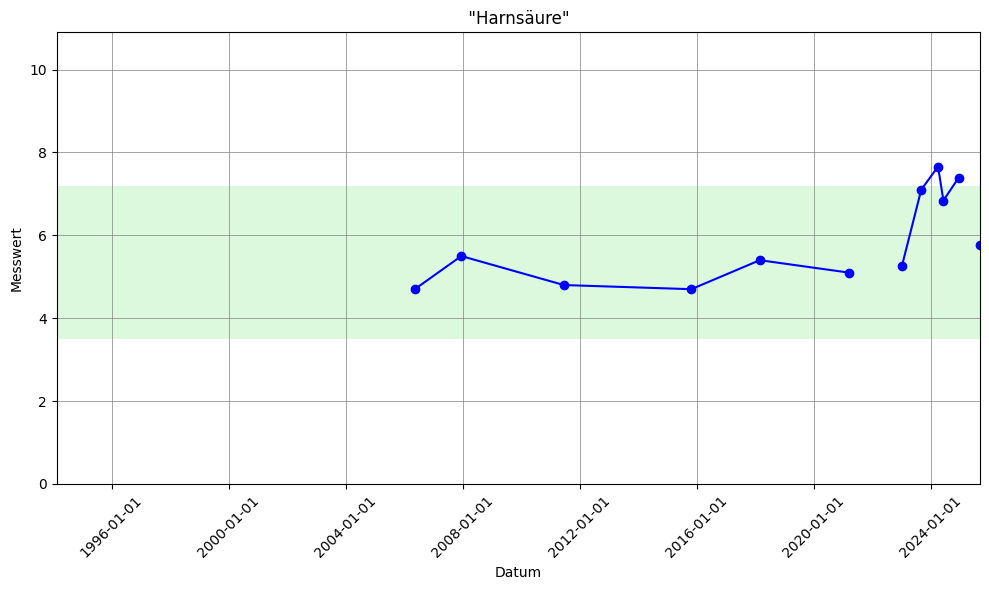

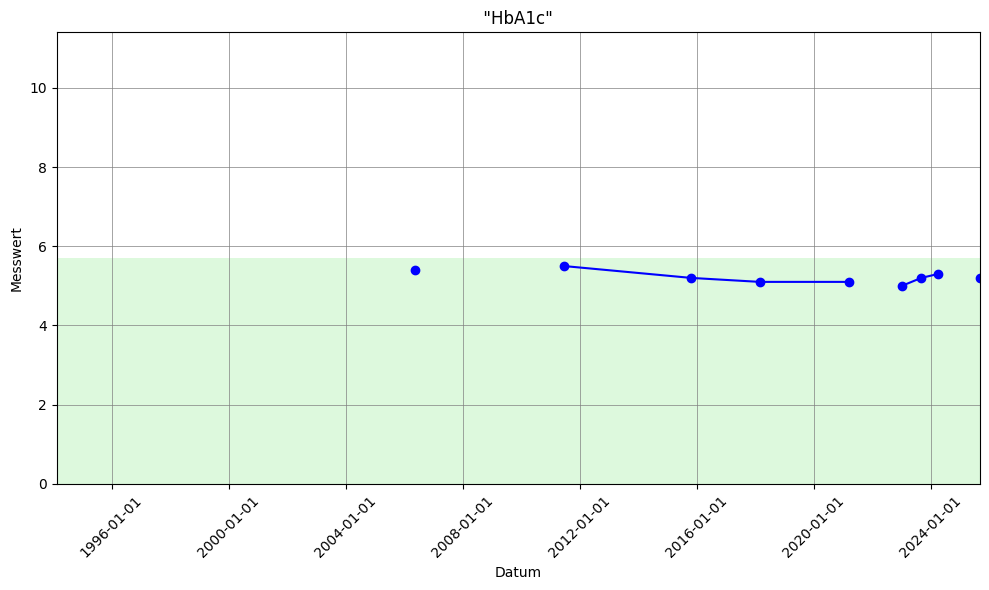

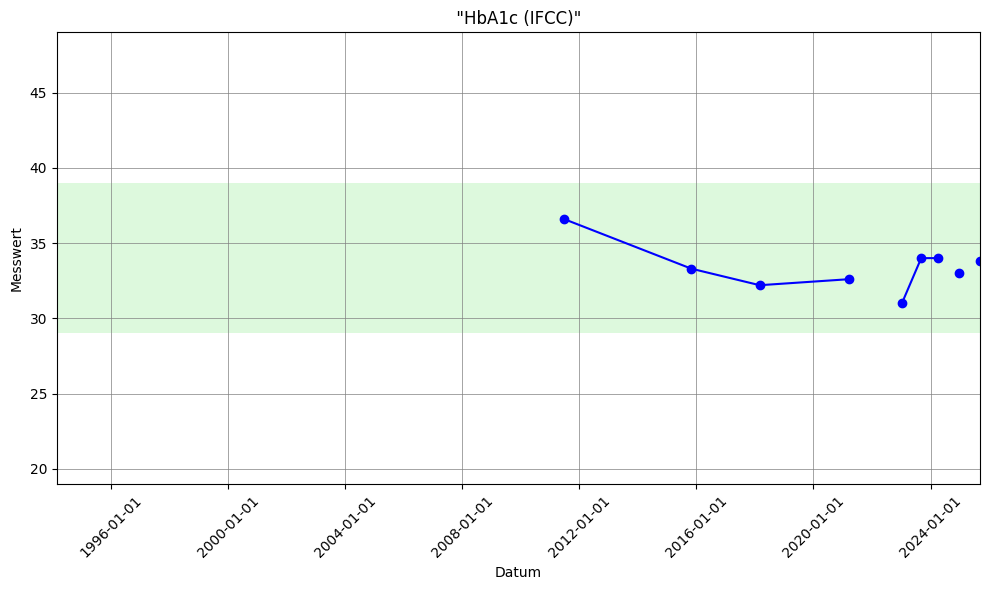

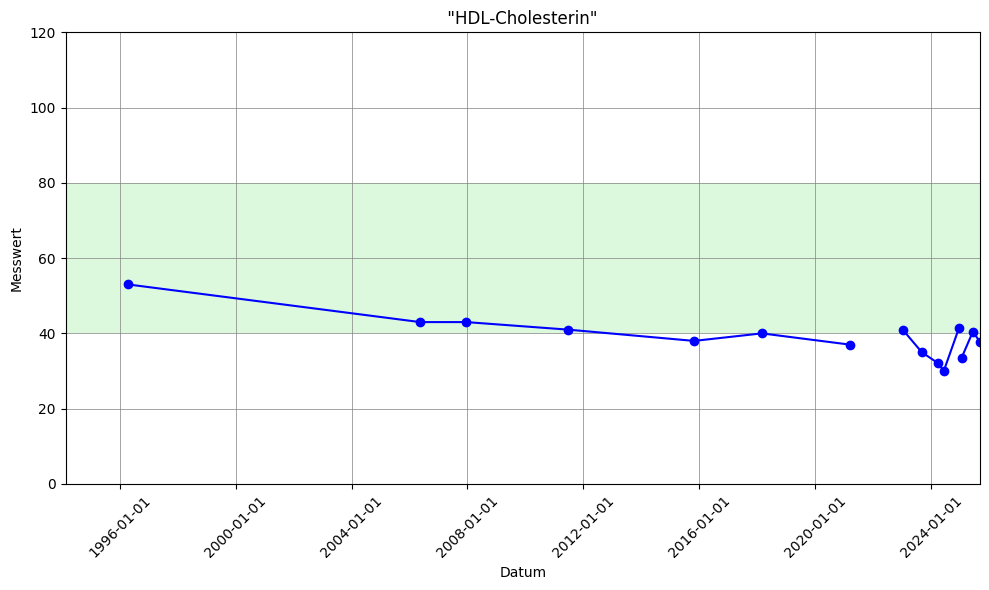

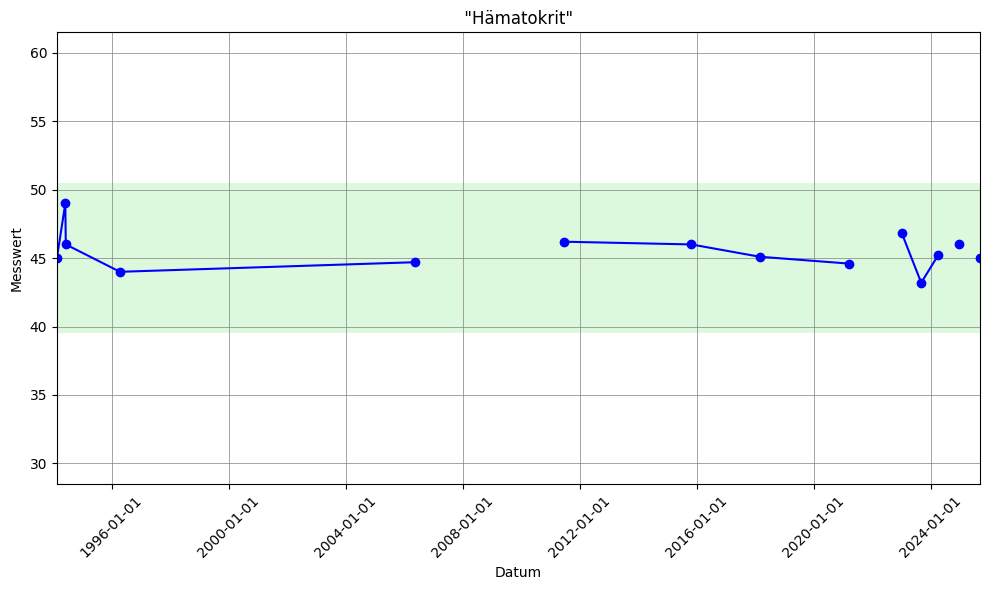

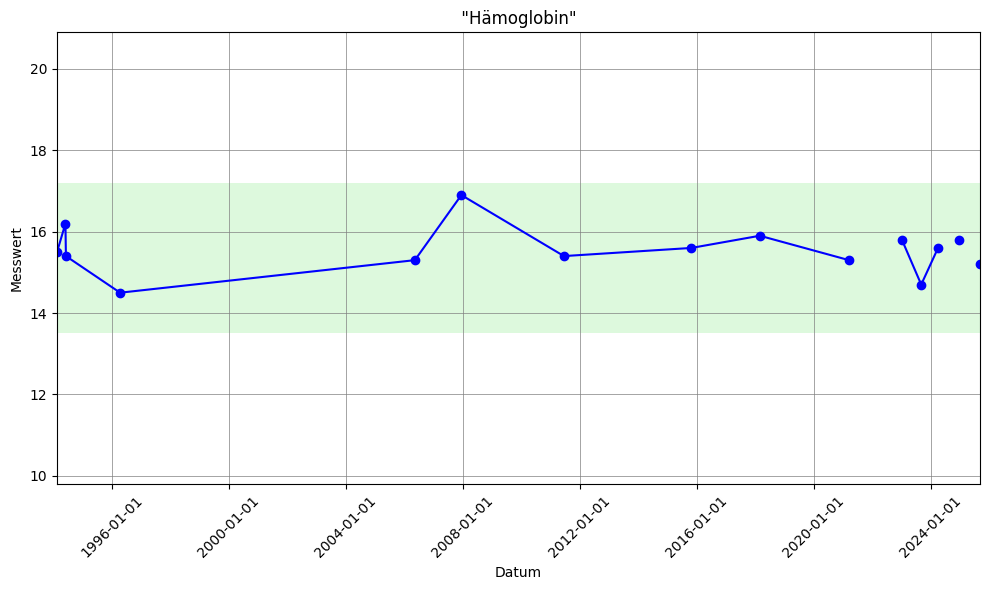

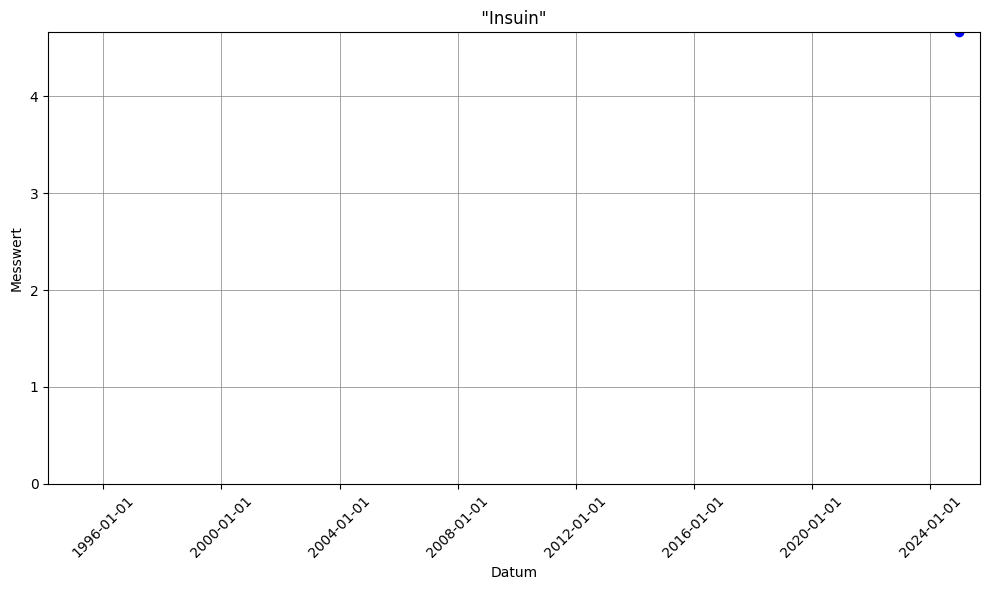

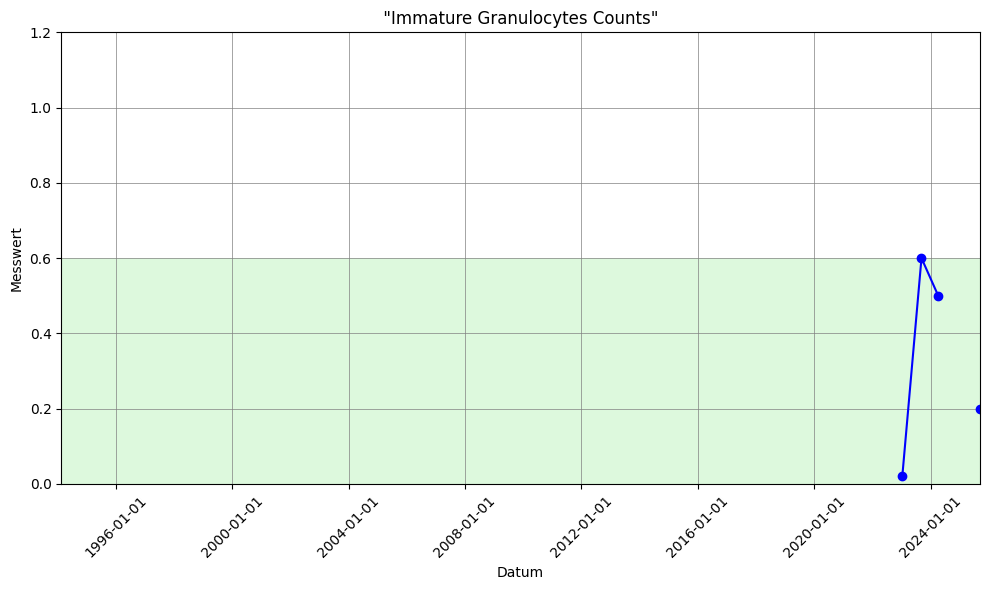

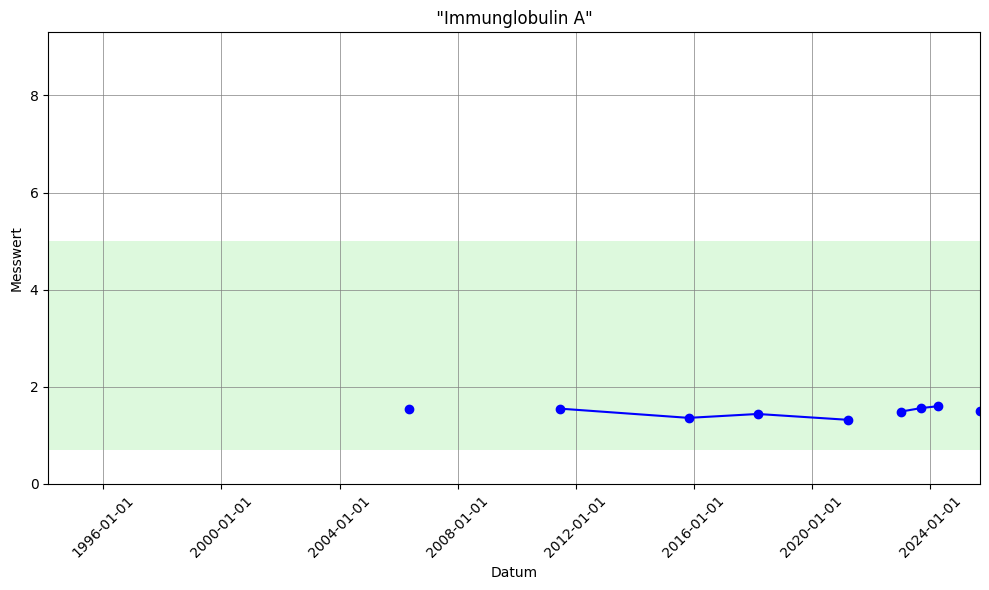

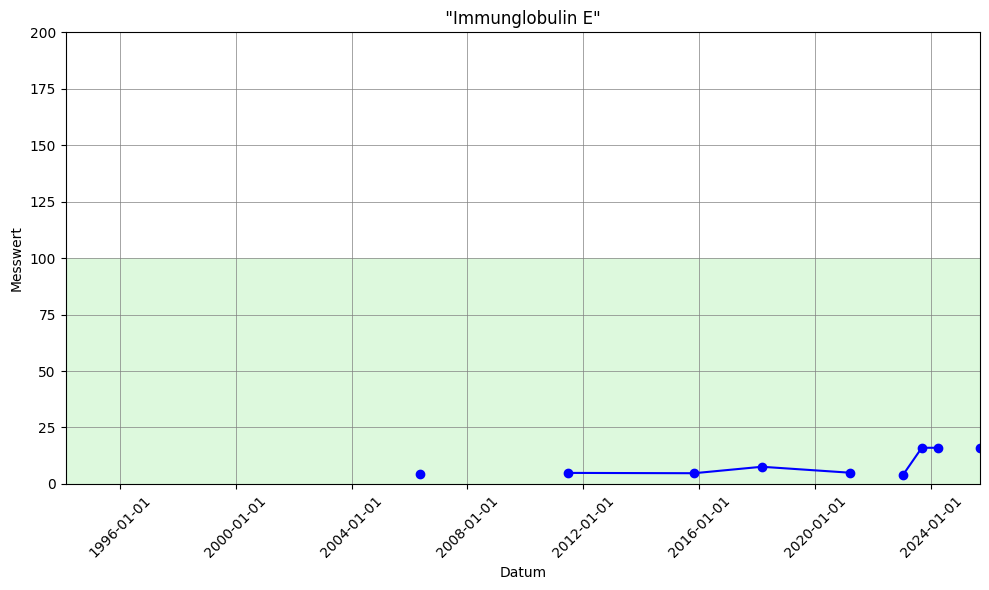

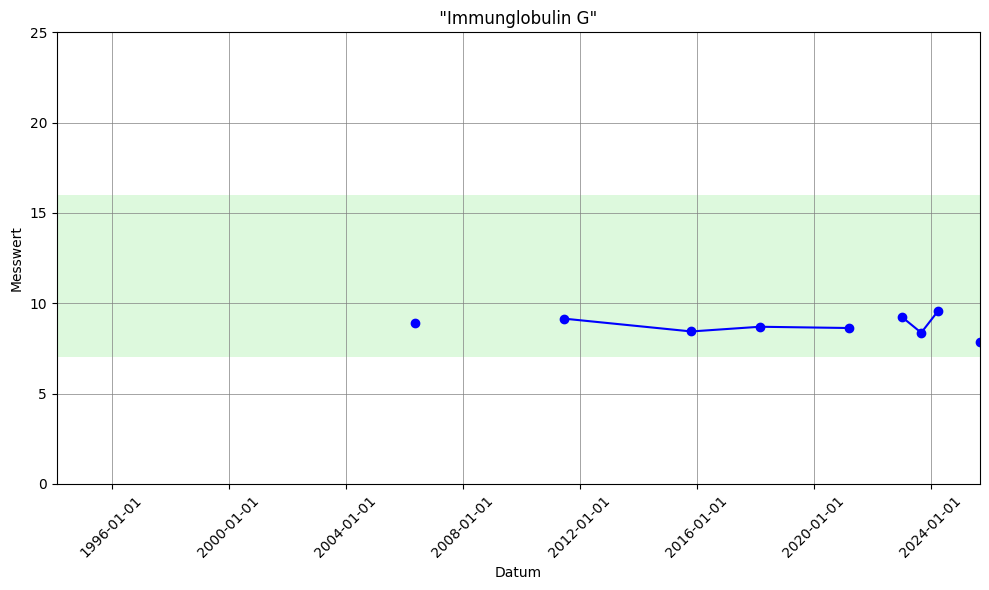

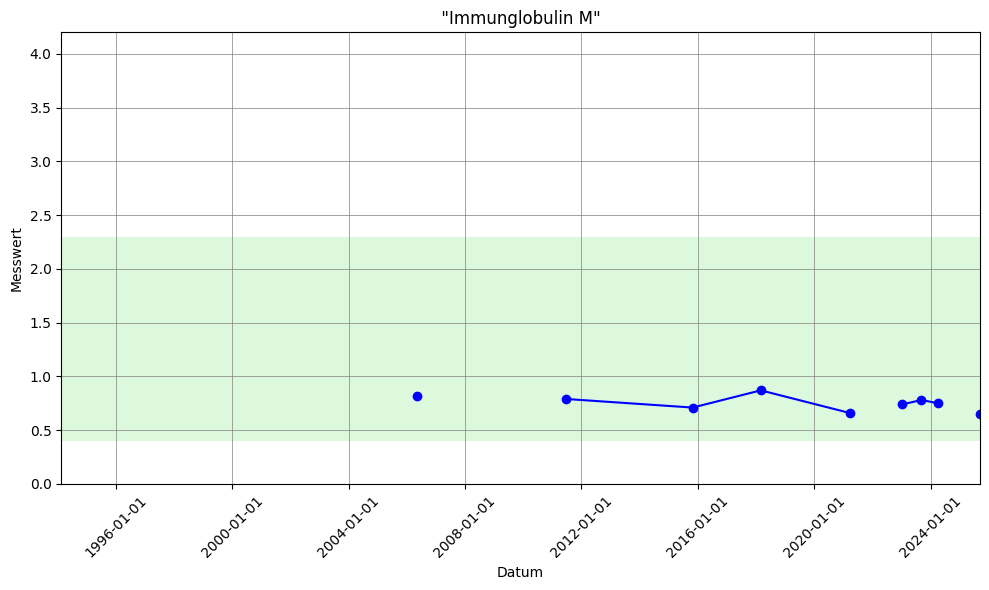

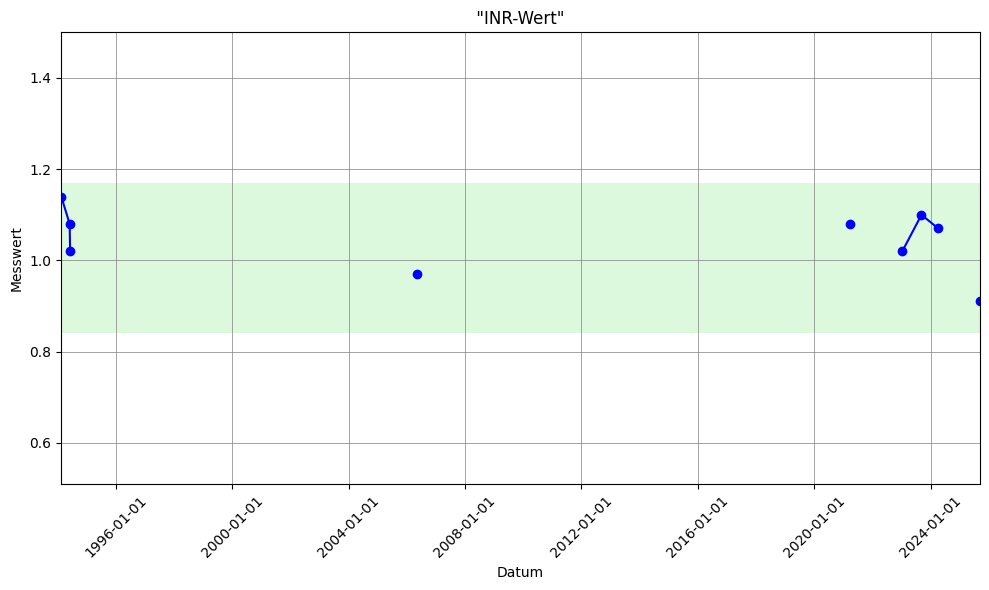

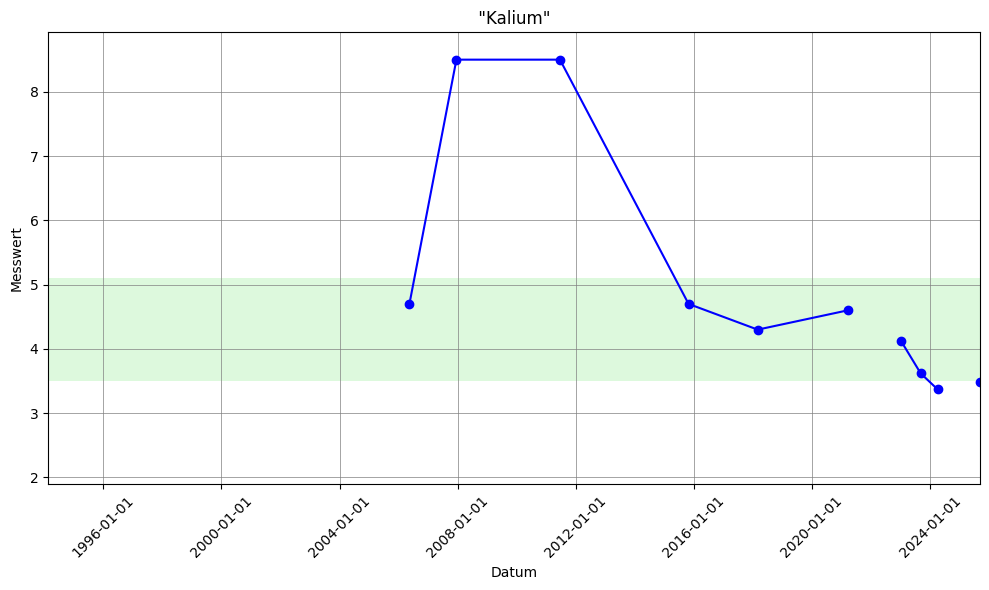

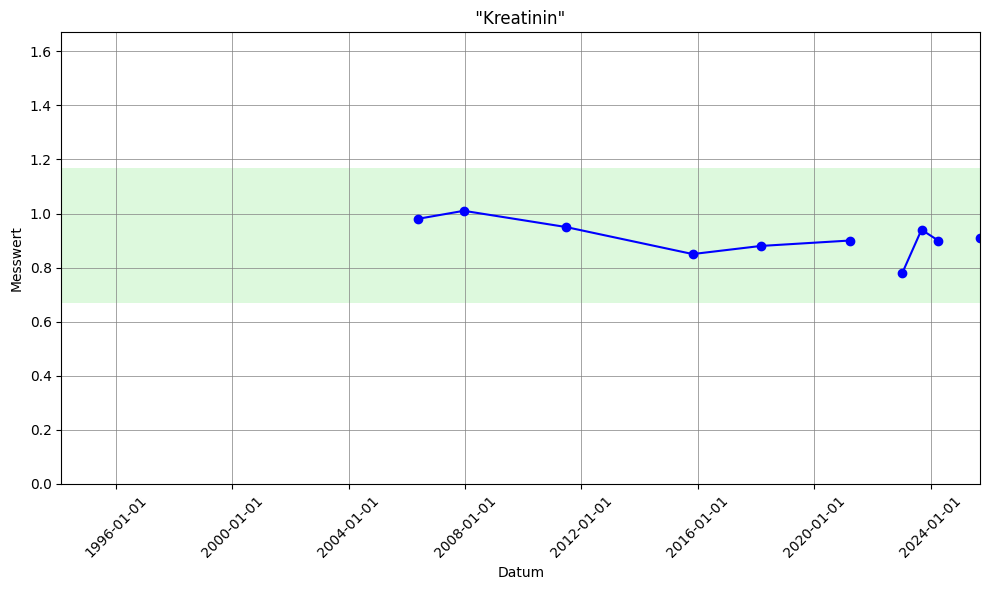

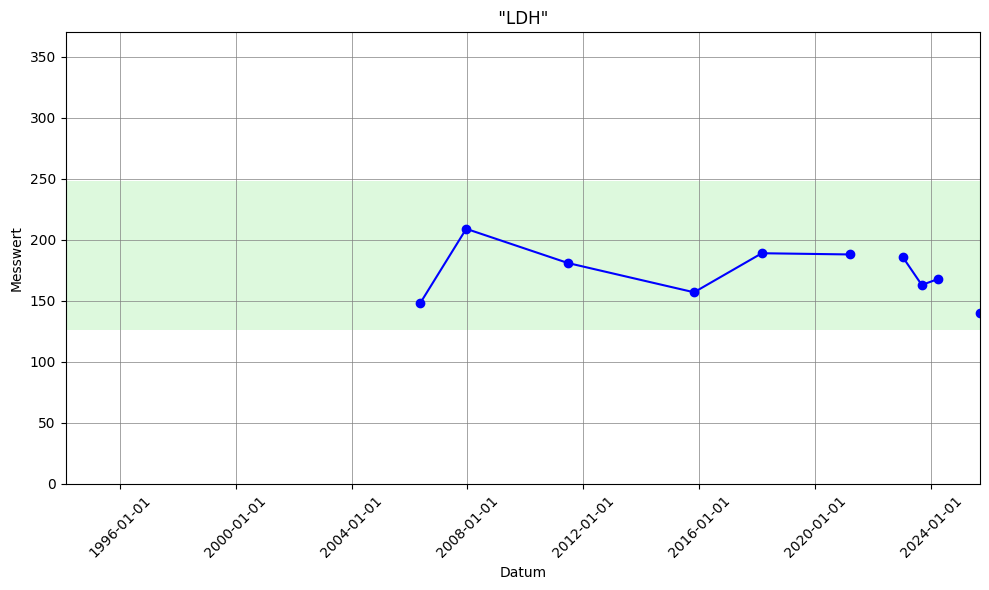

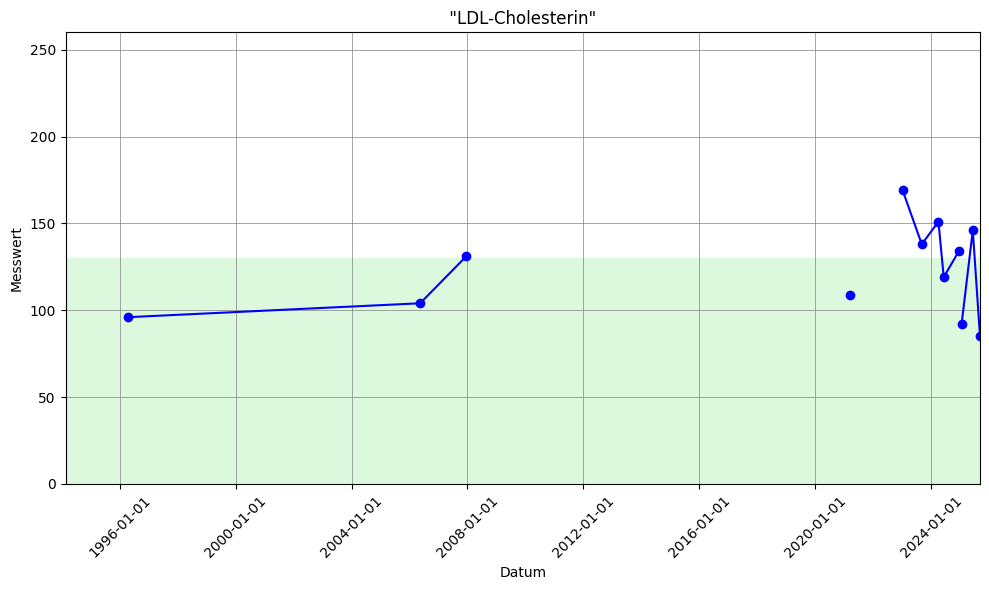

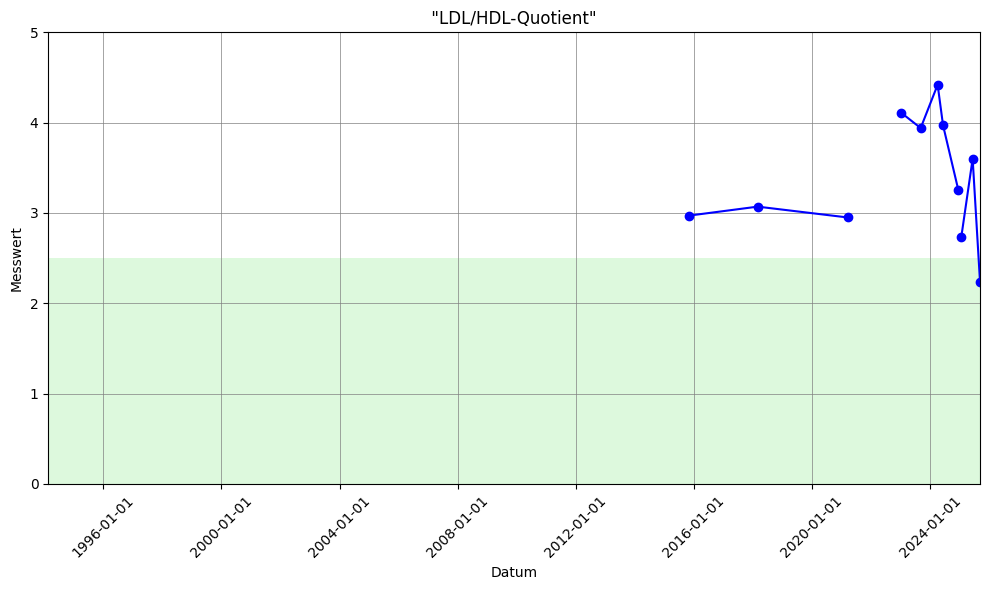

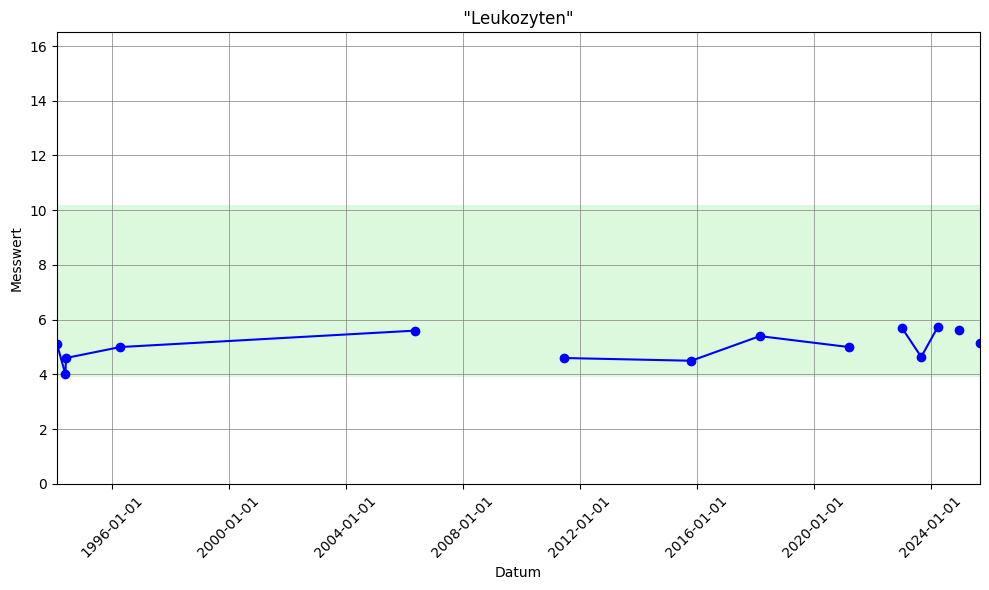

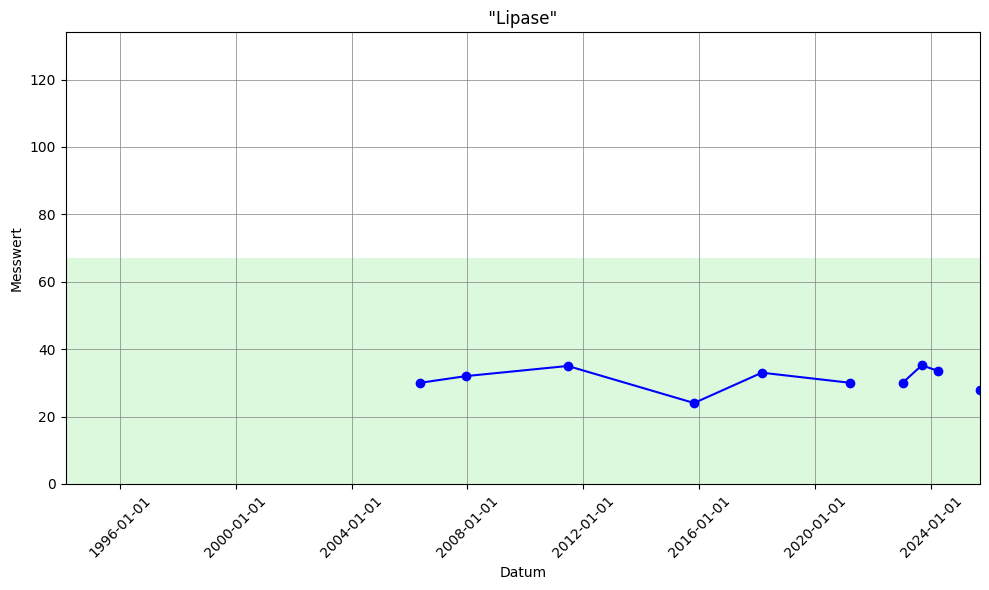

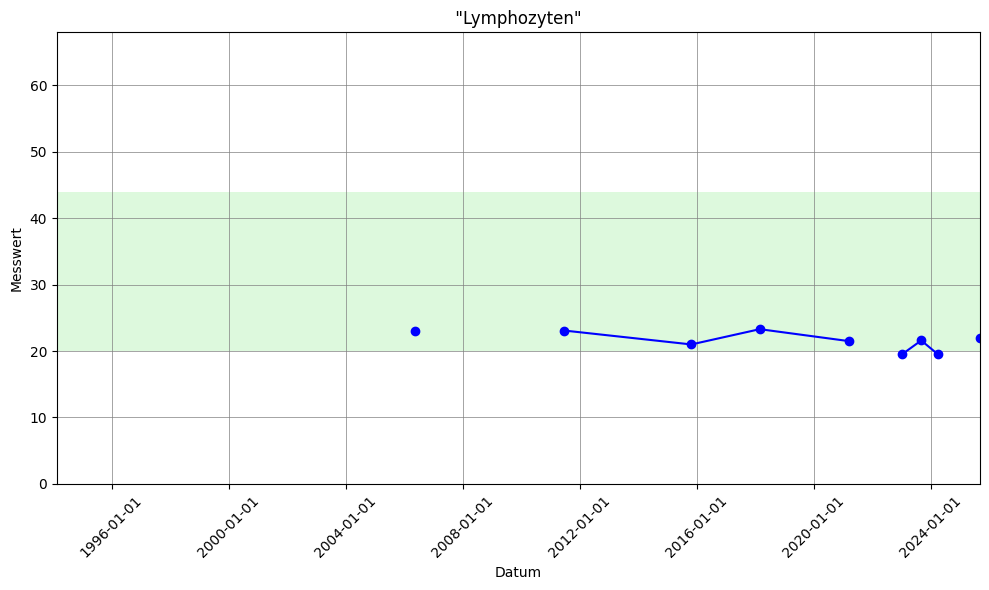

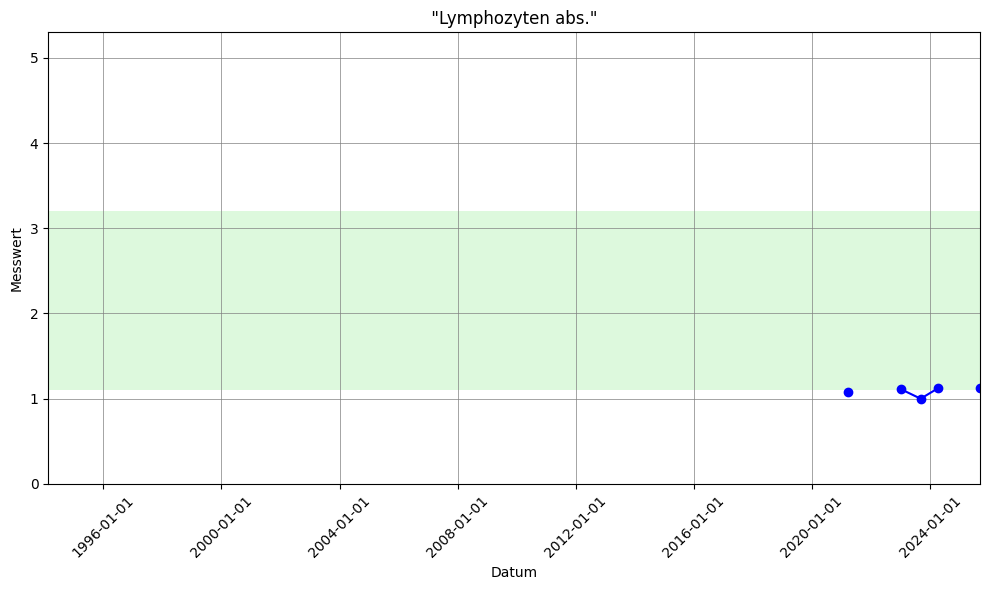

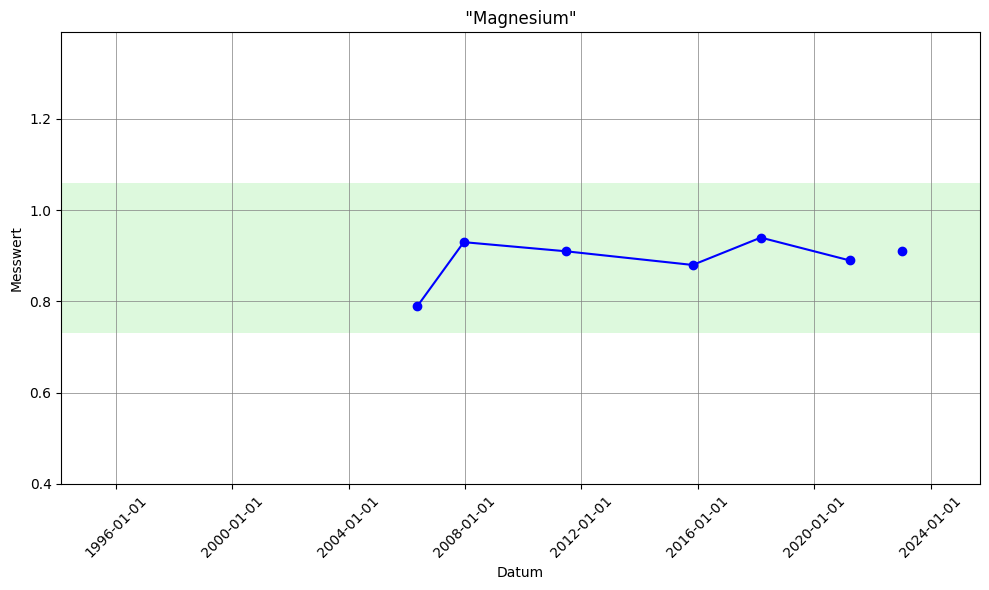

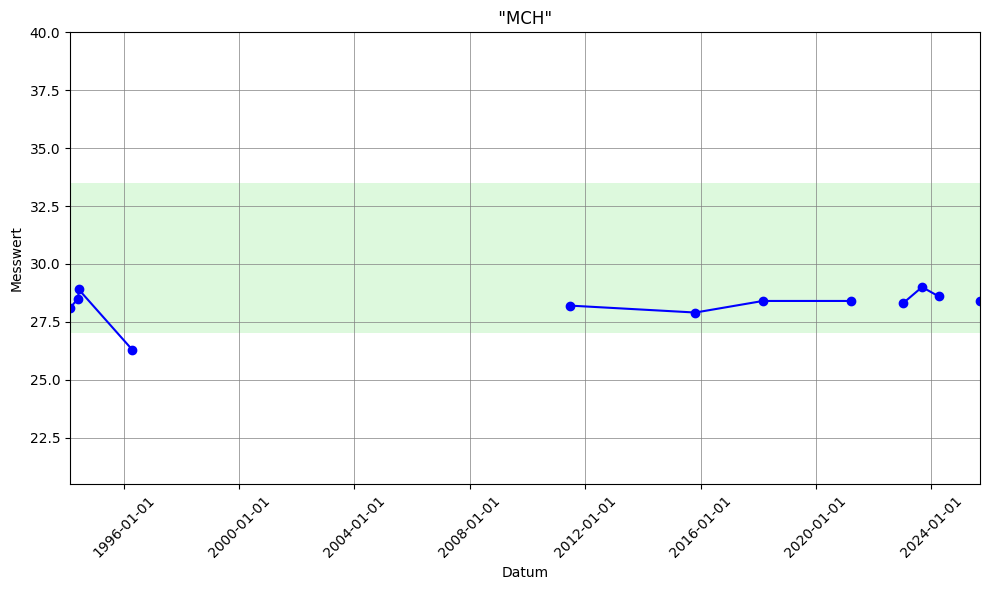

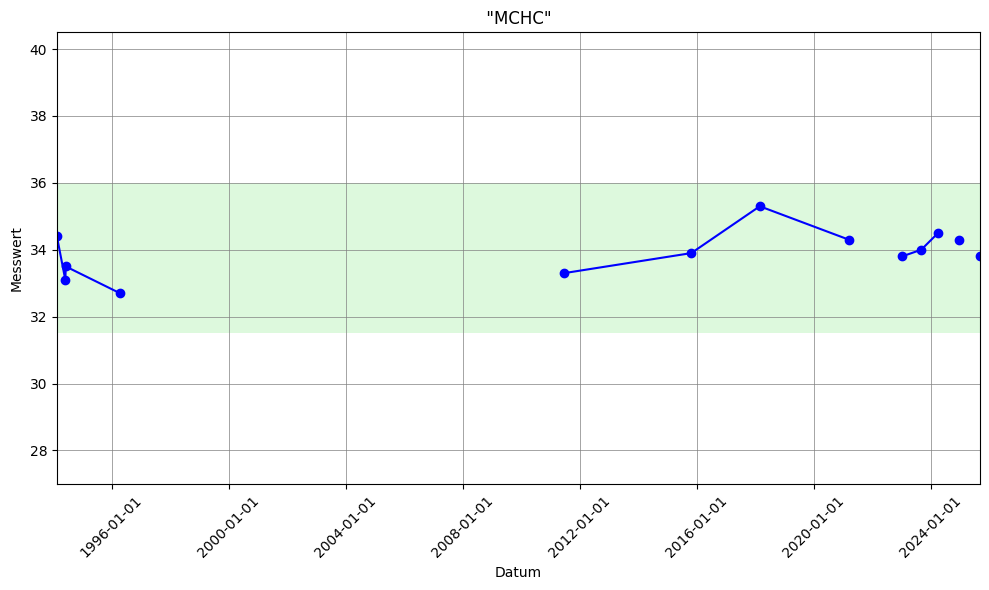

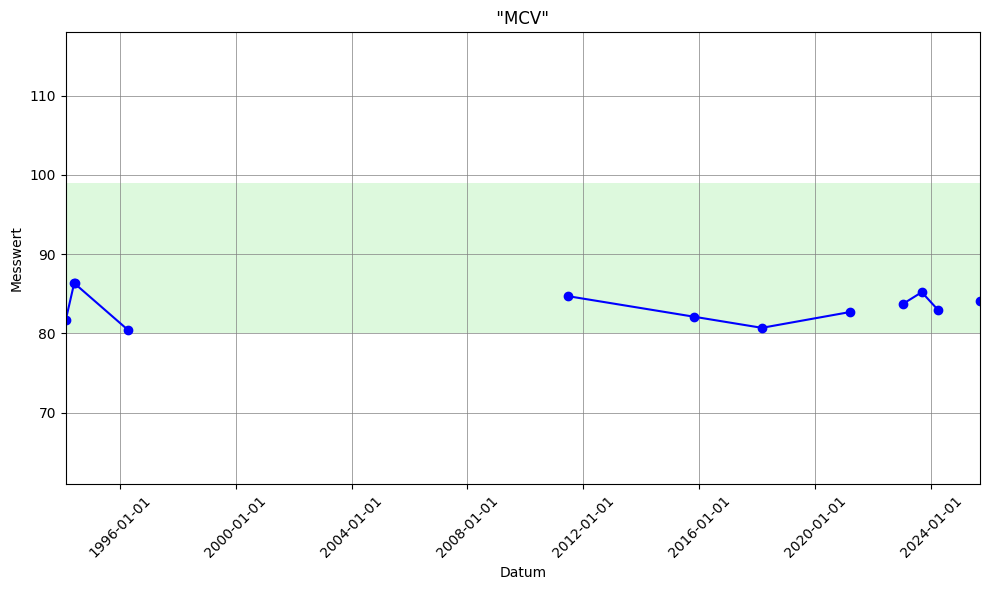

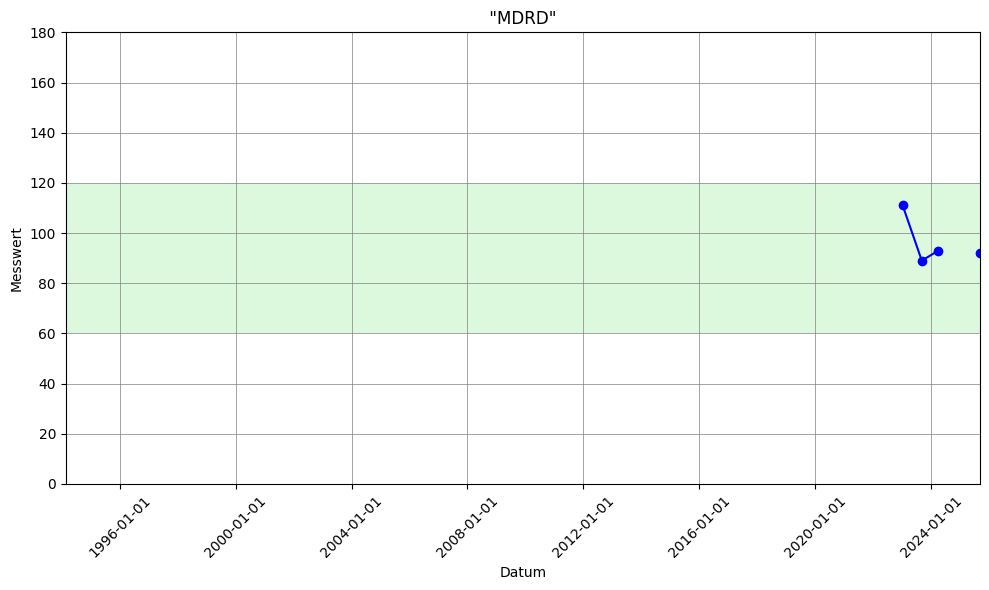

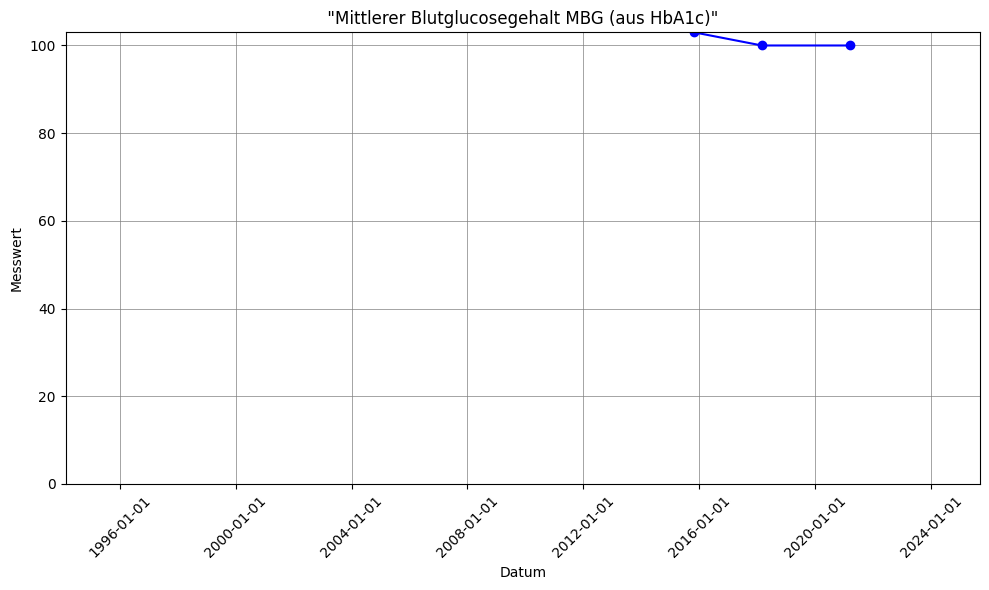

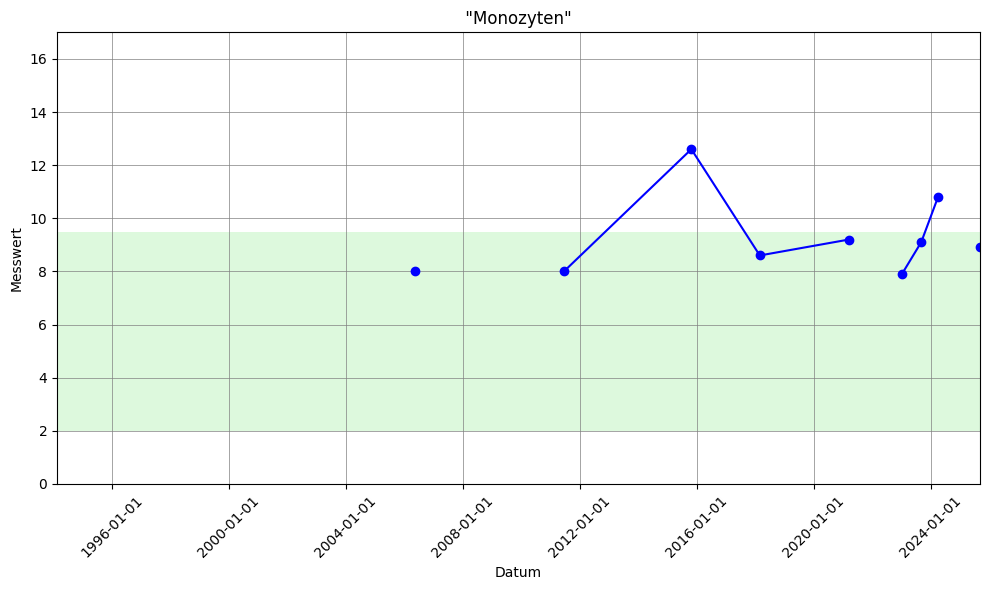

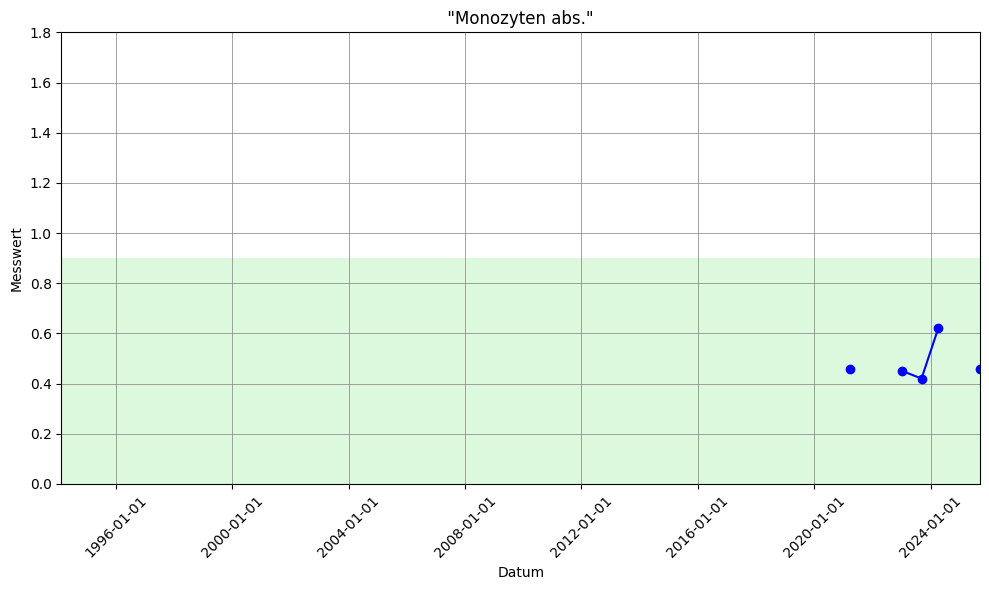

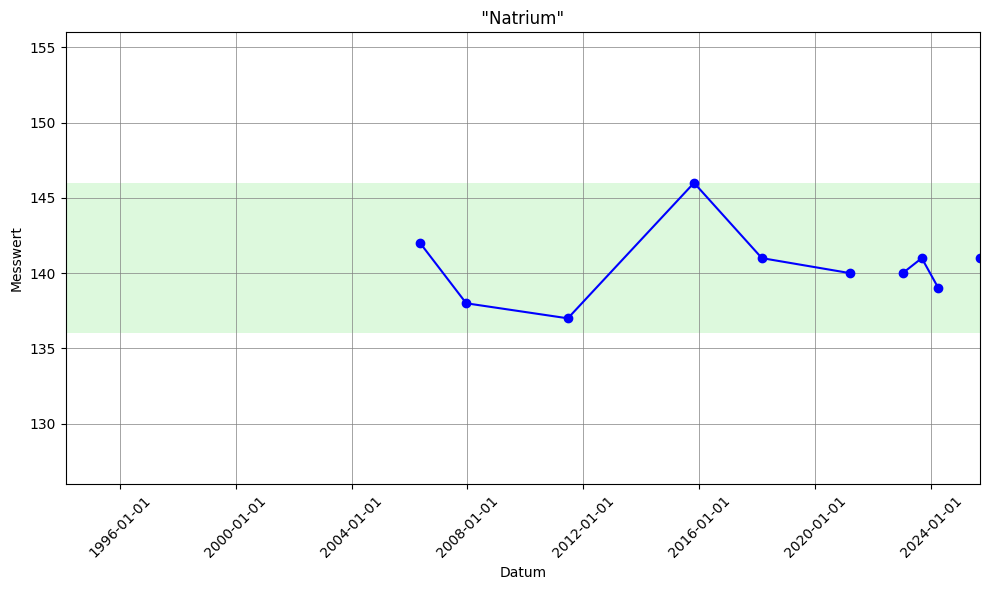

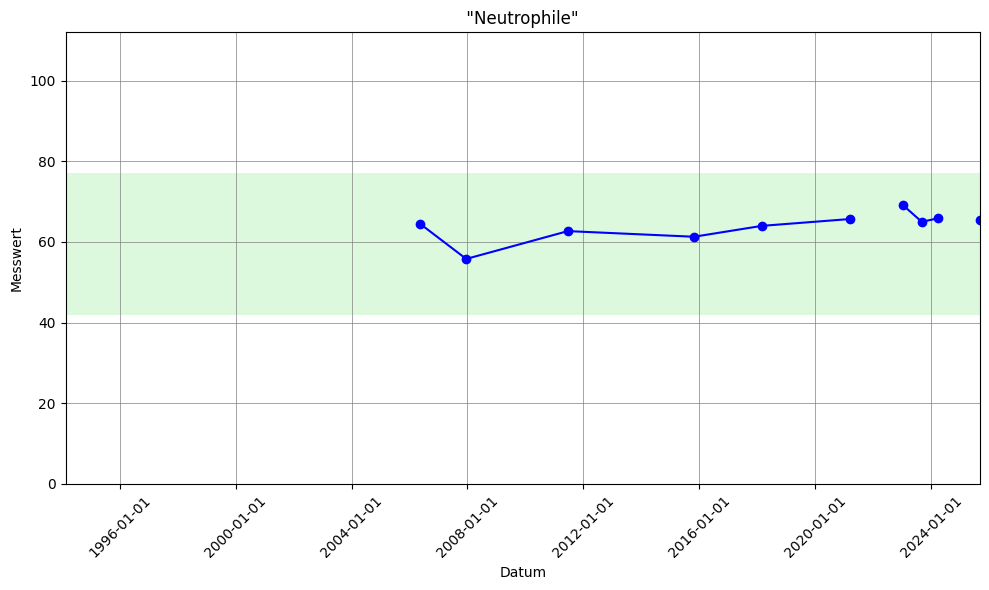

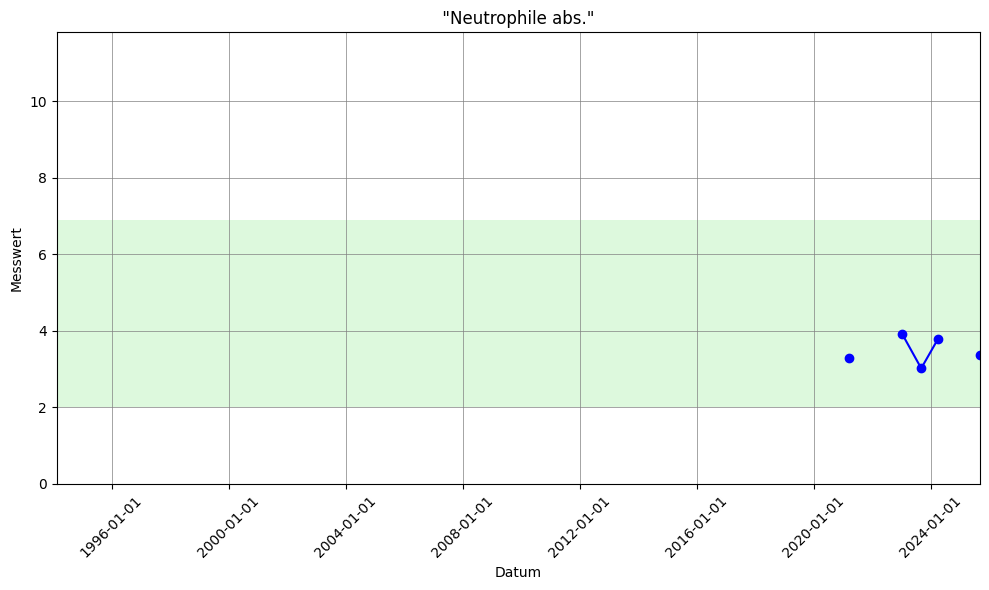

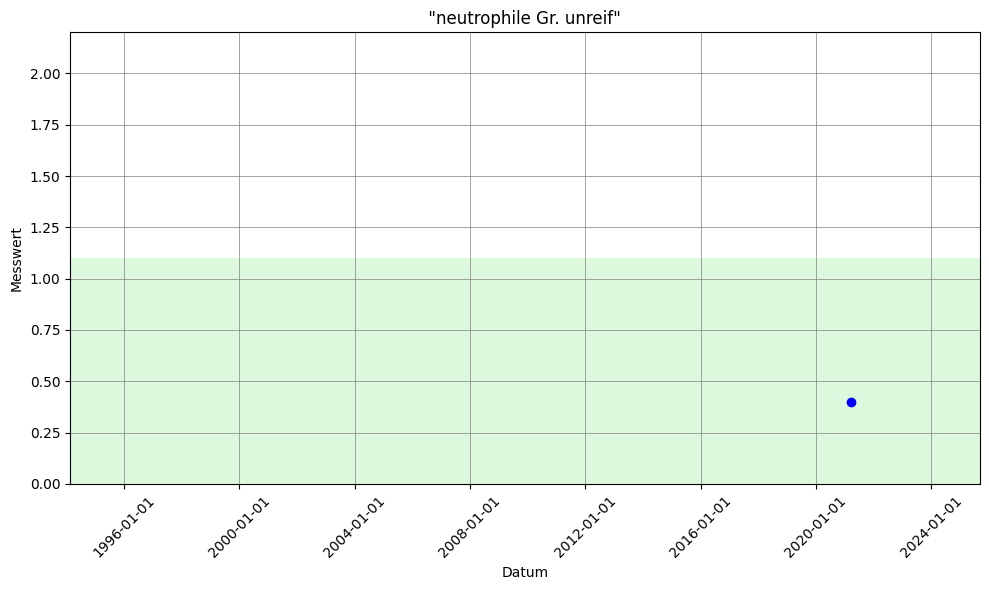

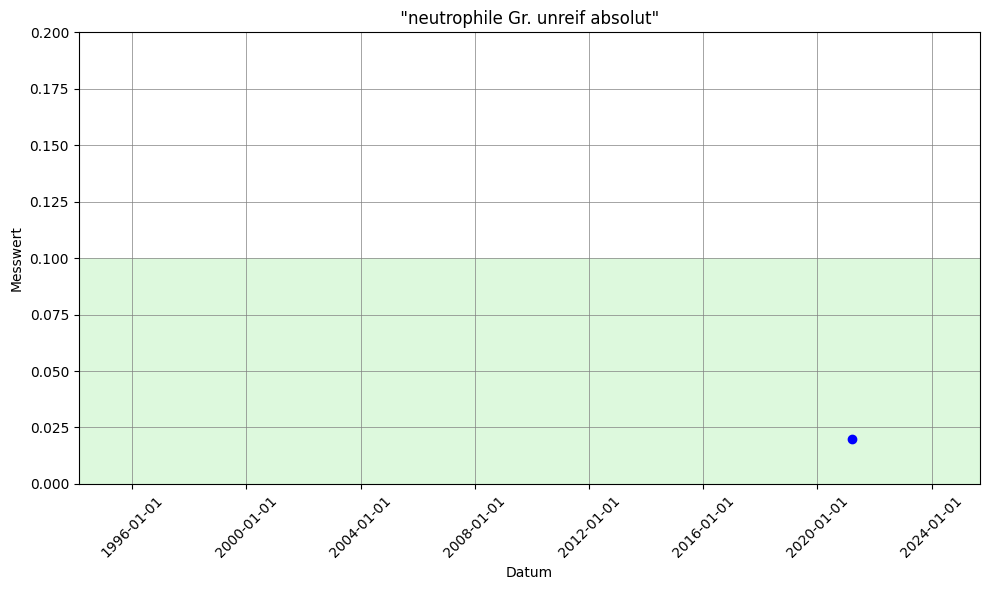

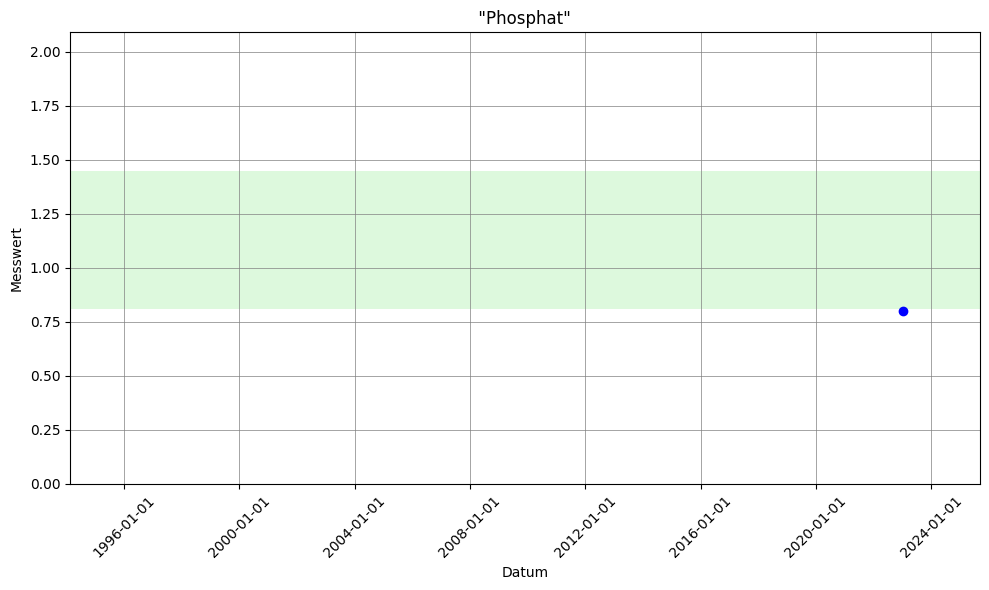

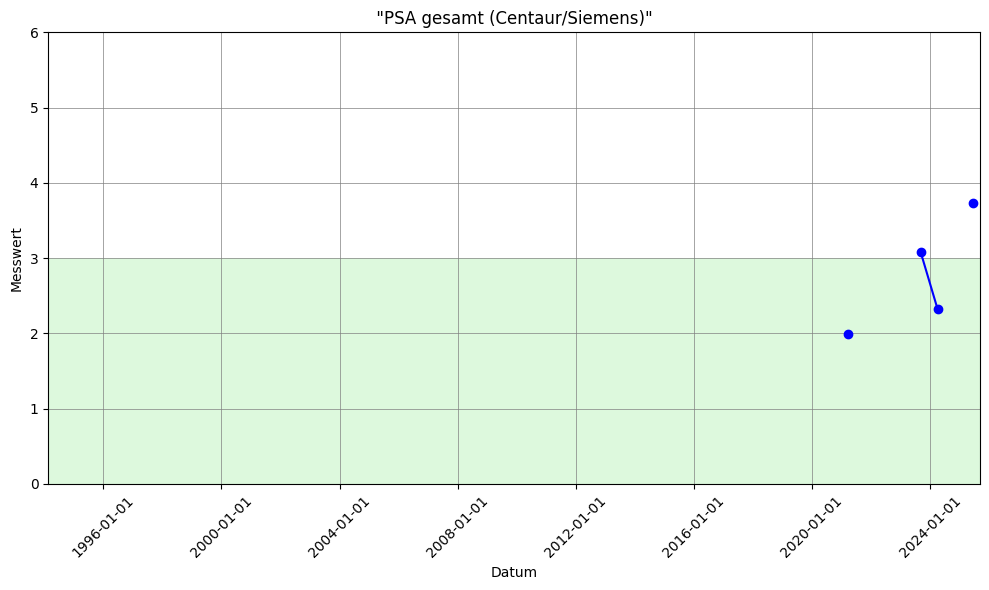

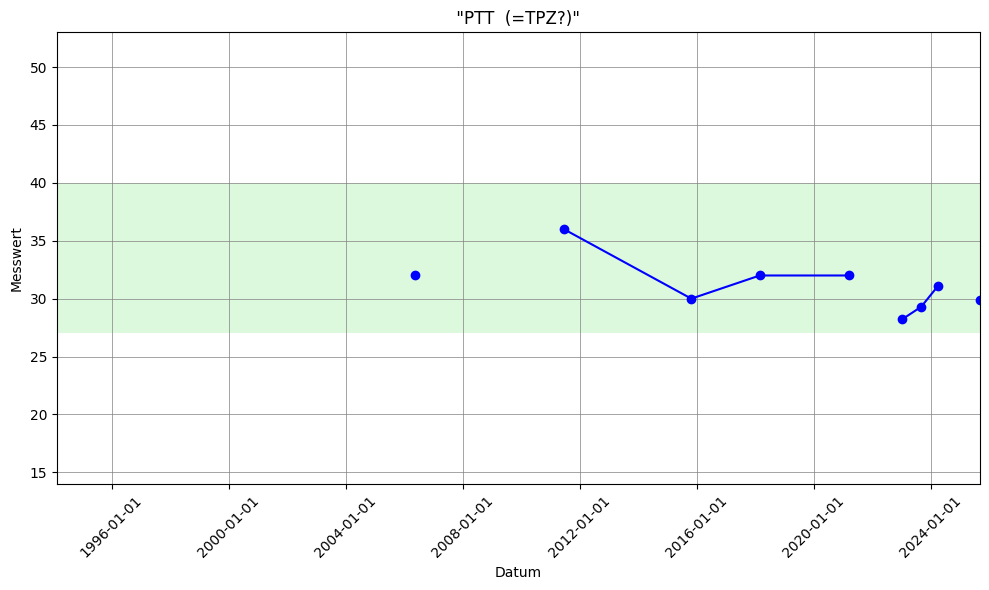

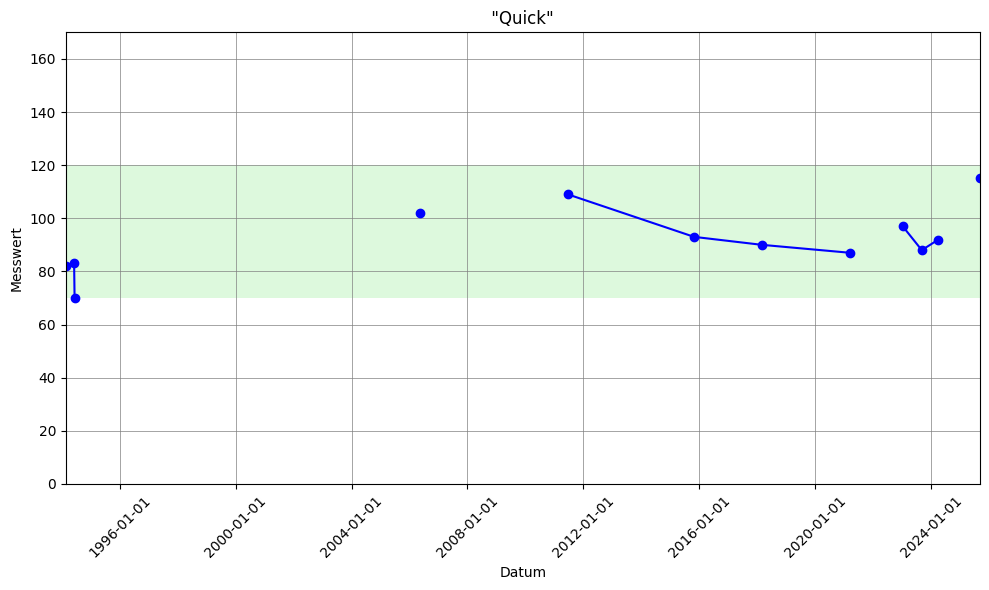

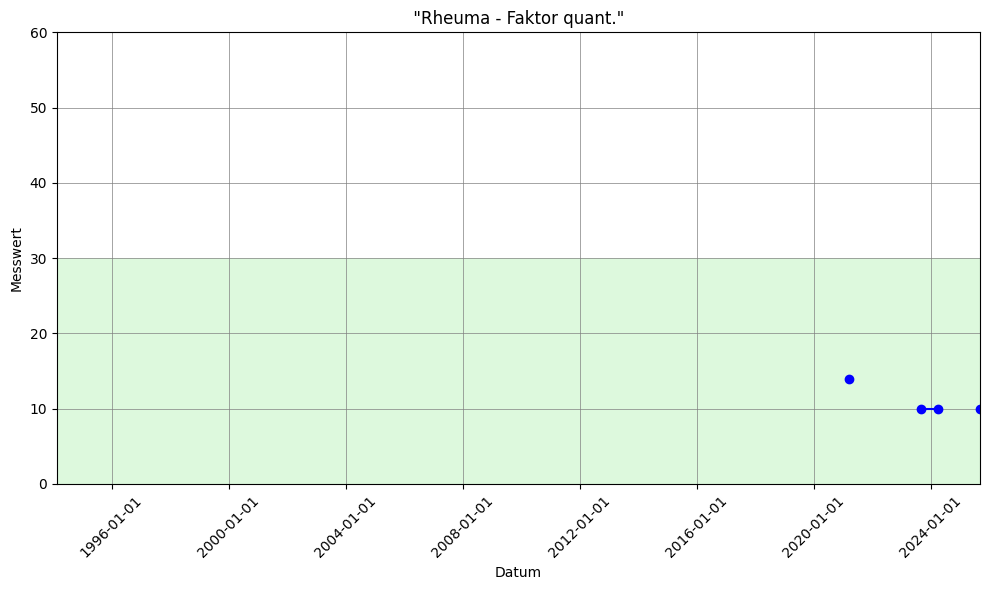

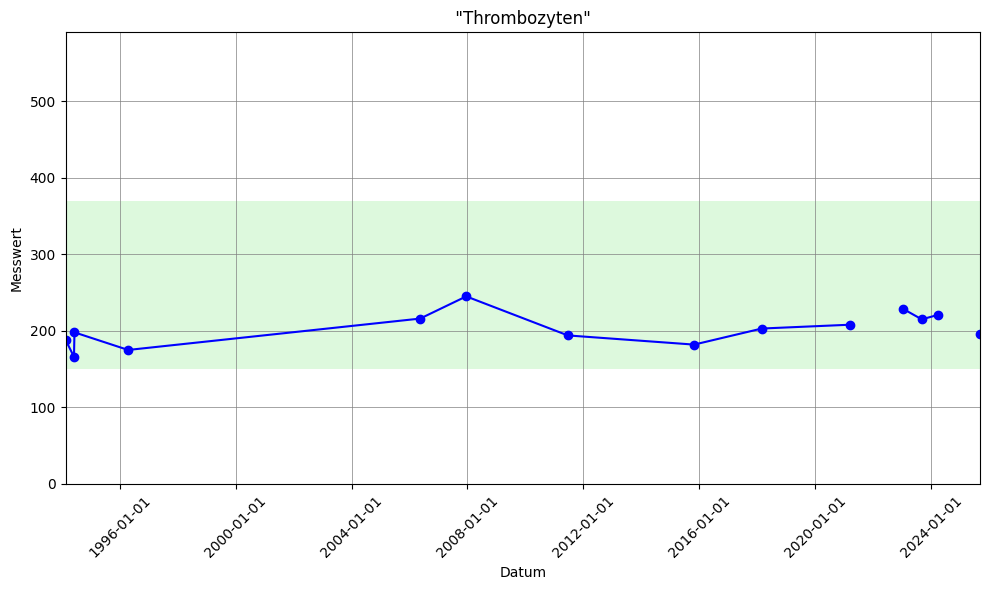

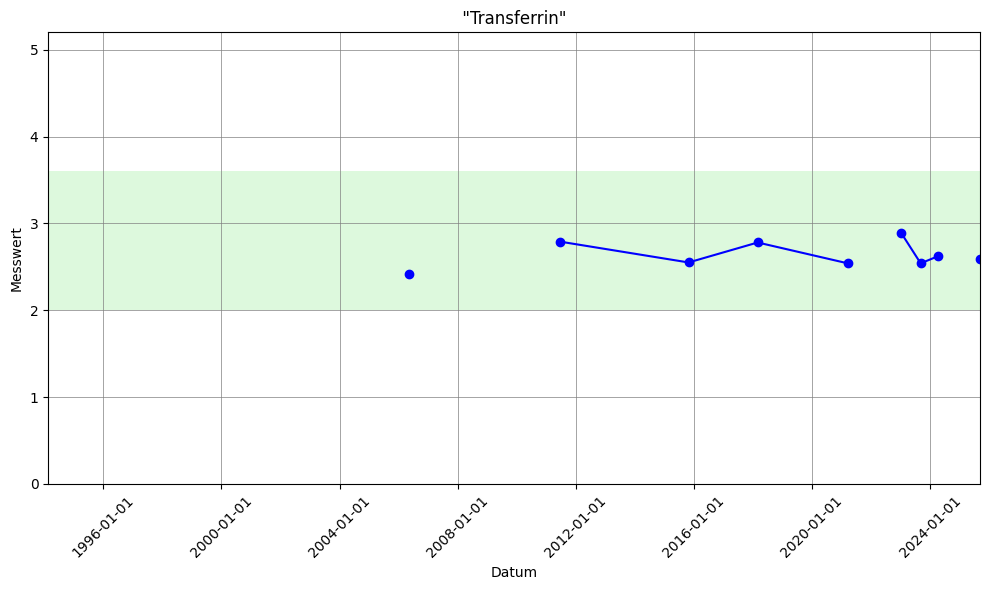

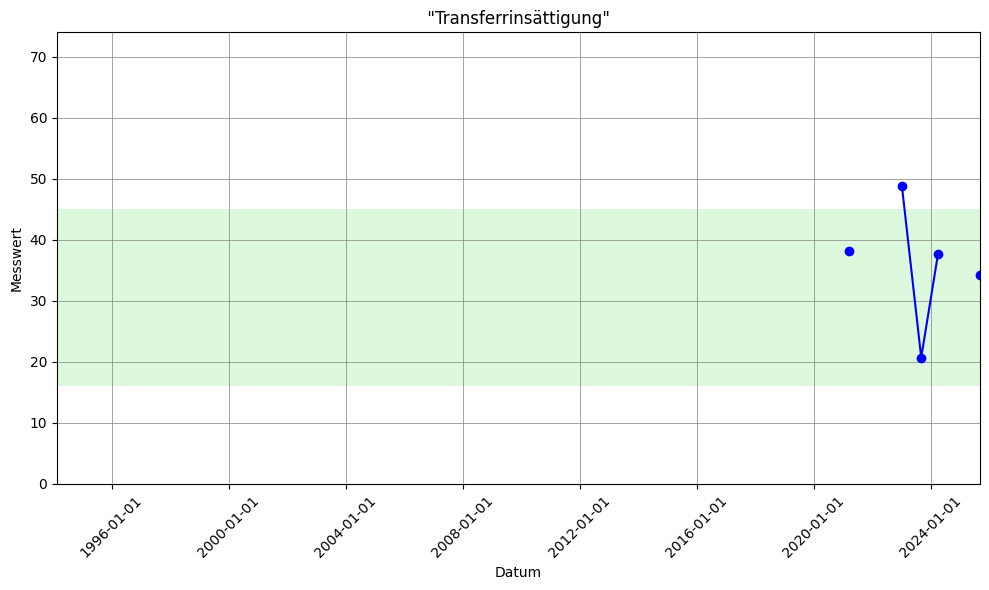

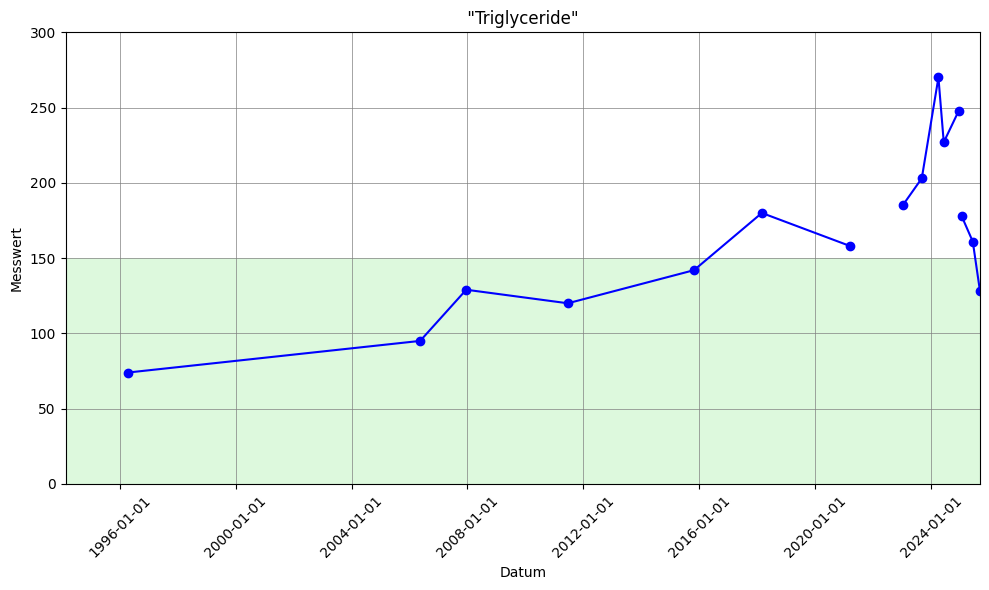

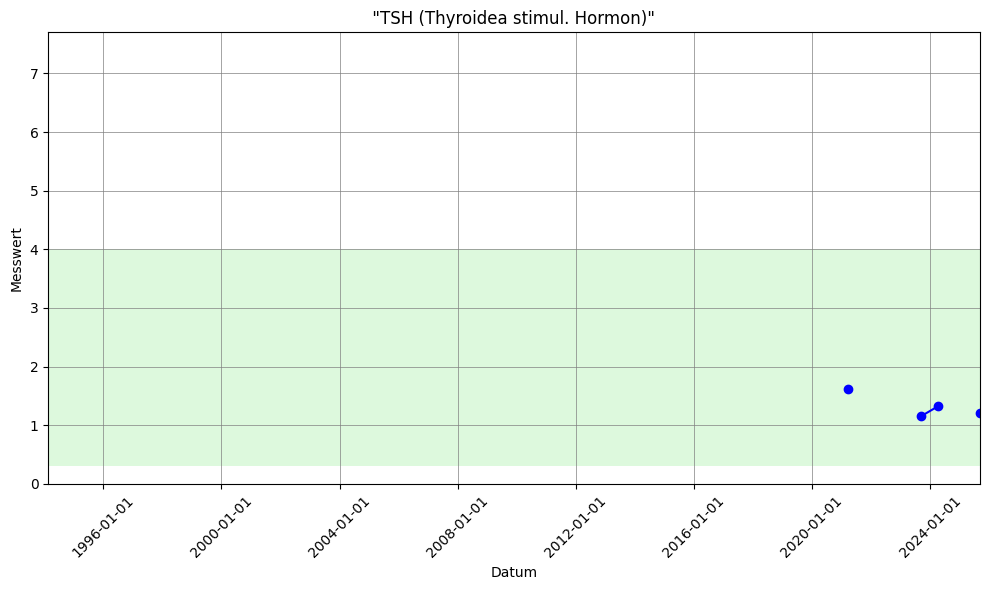

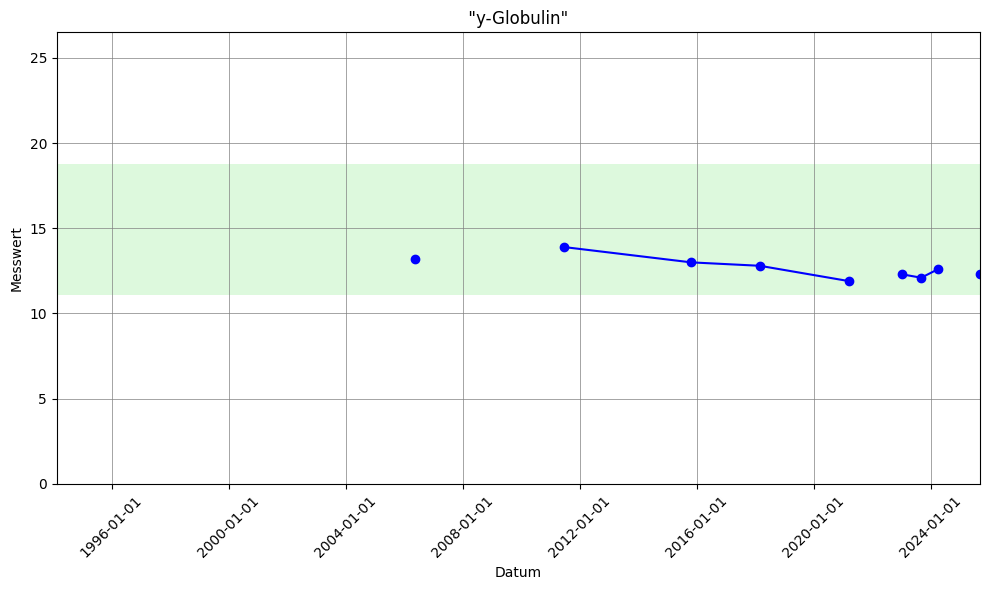

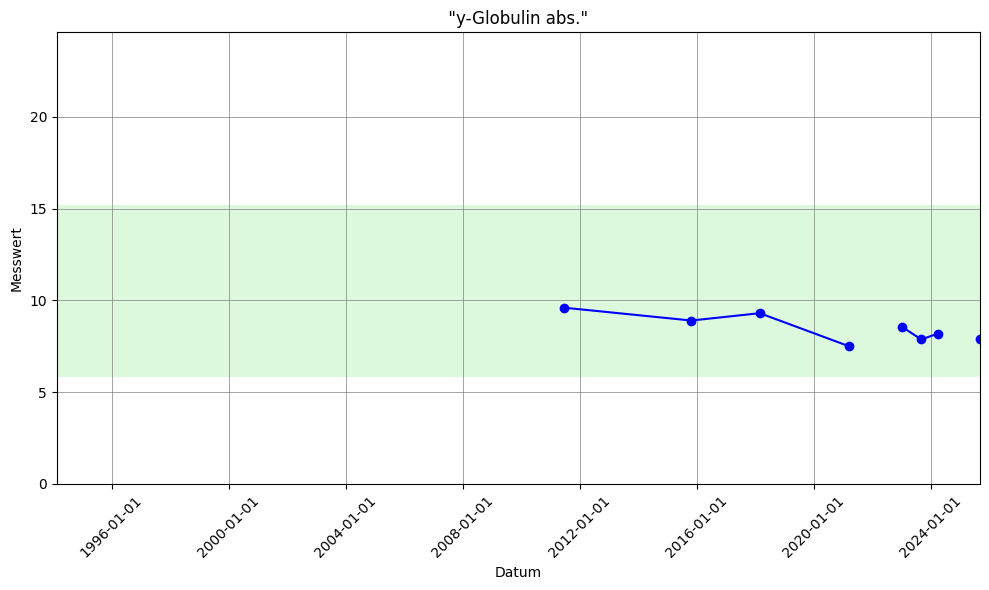

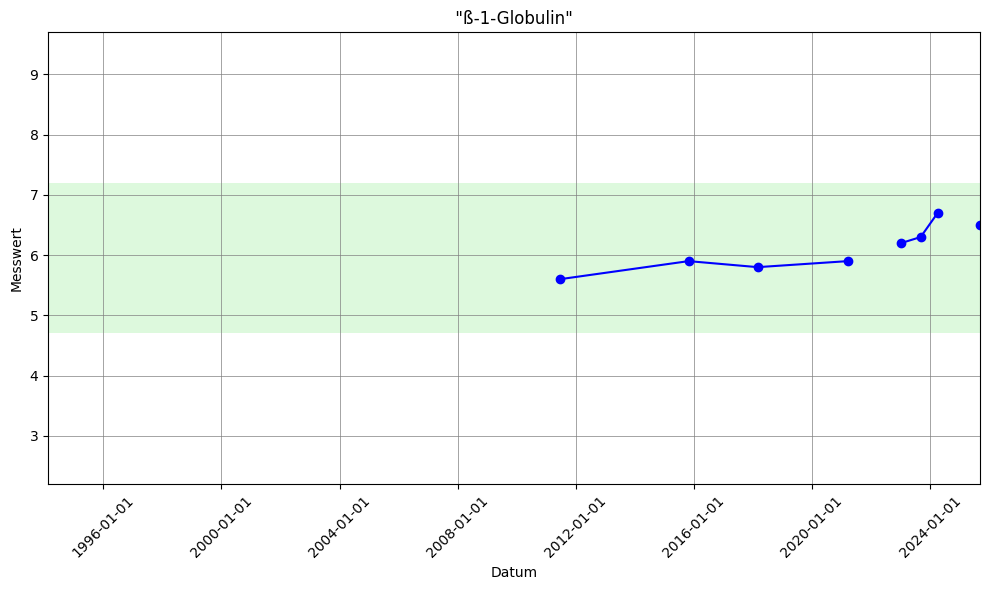

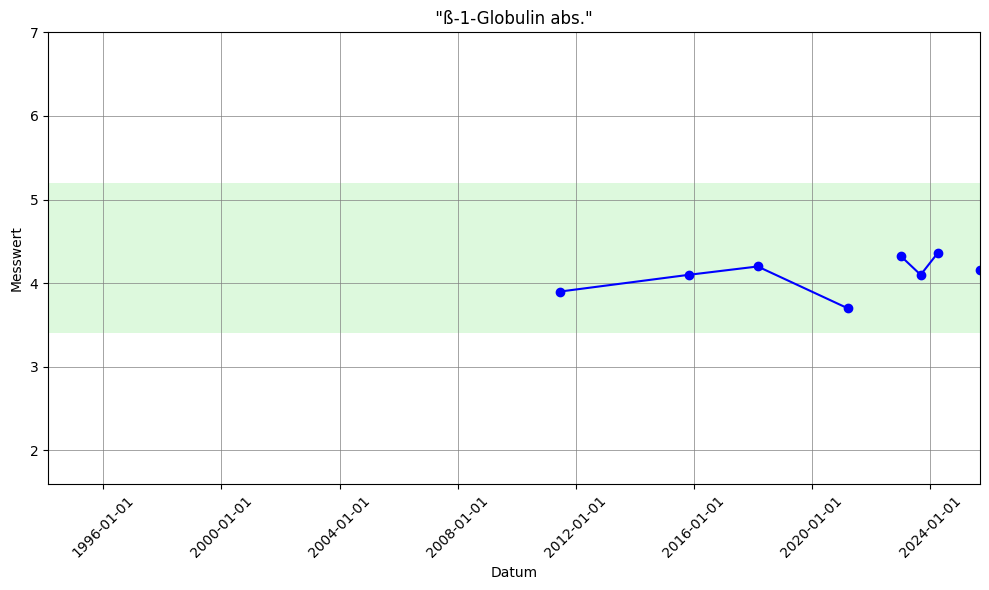

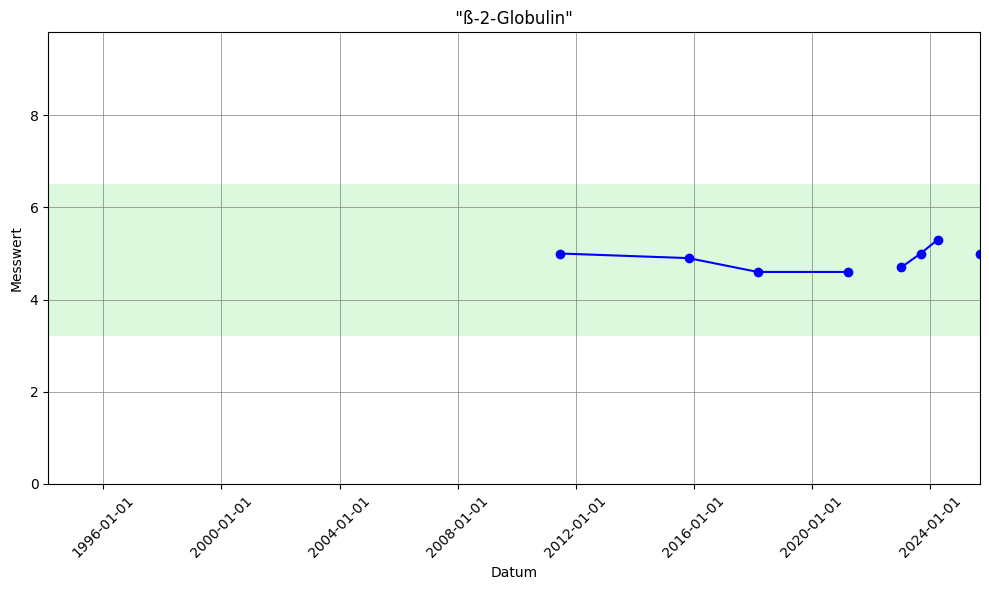

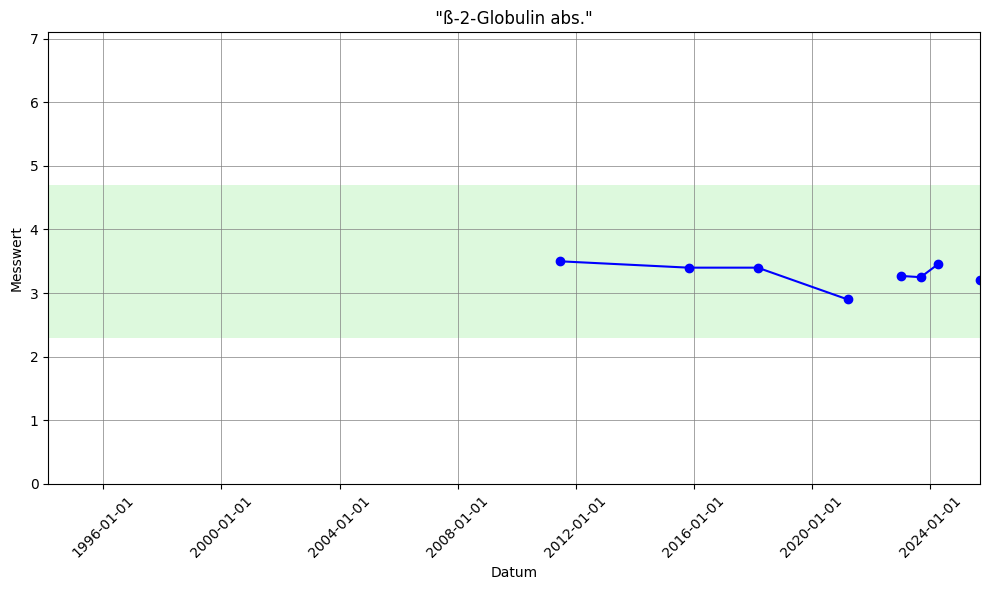

ValueError: could not convert string to float: '0.00?'

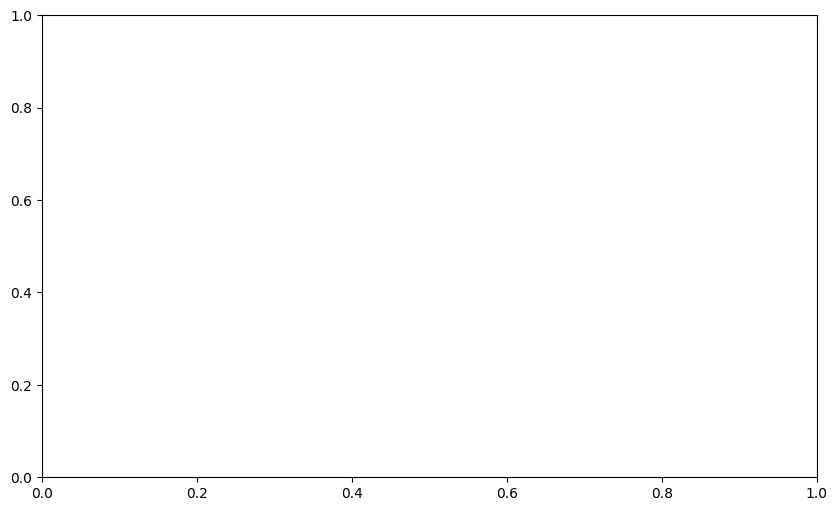

In [2]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ipywidgets as widgets
from IPython.display import display, clear_output

# Daten aus der CSV-Datei laden
data = pd.read_csv('blutbild.csv')

# Funktion zum Extrahieren des Normalbereichs aus dem Normalwert-Text
def extract_normal_range(normalwert):
    #print(f"{type(normalwert)}: '{normalwert}'")
    if not isinstance(normalwert,str):
        return None
    
    if normalwert.startswith("<"):
        max_value = float(normalwert[1:])
        return (0, max_value)
    elif normalwert.startswith("bis"):
        max_value = float(normalwert.replace("bis",""))
        return (0, max_value)
    elif normalwert.startswith("ab"):
        min_value = float(normalwert.replace("ab",""))
        return (min_value, min_value*2)
    elif "-" in normalwert:
        min_value, max_value = normalwert.split("-")
        return (float(min_value), float(max_value))
    else:
        return None

def get_y_axis_range(normalwert_range, measurements, threshold_percent=50):
    """
    Calculate the y-axis range for a plot based on the normalwert_range and actual measurements.
    The range is extended above and below the normalwert_range by the range itself.

    Args:
        normalwert_range (tuple): A tuple containing the minimum and maximum values of the normal range.
        measurements (list): A list of measurement values.
        threshold_percent (float): The percentage of the range below which y_min is adjusted to 0.

    Returns:
        tuple: A tuple containing the extended minimum and maximum values for the y-axis range.
    """
    values = [measurement for measurement in measurements if not math.isnan(measurement)  ]

    if normalwert_range is None:
        # If normalwert_range is not available, set default y-axis range
        y_min = min(0, min(values, default=0))
        y_max = max(1, max(values, default=1))
    else:
        min_value, max_value = normalwert_range
        min_measurement = min(values, default=min_value)
        max_measurement = max(values, default=0)
        # Calculate the extended y-axis range above and below the normalwert_range
        y_range = max_value - min_value
        y_min = max(0, min_value - y_range)
        
        # Calculate the threshold as a percentage of the range
        threshold_value = threshold_percent / 100 * y_range
        
        # Adjust y_min to 0 if it's smaller than the threshold
        if 0 <= y_min <= threshold_value:
            y_min = 0
        
        y_max = max(max_value + y_range, max_measurement * 1.05 )

    return (y_min, y_max)

# Funktion zum Erstellen des Plots
def plot_data(messwert):
    fig, ax = plt.subplots(figsize=(10, 6))    
    
    # Daten für den ausgewählten Messwert filtern
    selected_data = data[data['Wert'] == messwert]
    
    # Normalbereich extrahieren
    normalwert = selected_data['Normalwert'].iloc[0]
    #print(f'"{normalwert}"')
    normal_range = extract_normal_range(normalwert)
    
    # x-Werte als Datumsobjekte interpretieren
    dates = pd.to_datetime(selected_data.columns[4:])

    # Set the x-axis range to min and max dates
    min_date = min(dates)
    max_date = max(dates)
    ax.set_xlim(min_date, max_date)

    # Calculate and set the y-axis range
    y_axis_range = get_y_axis_range(normal_range, selected_data.values[0][4:].astype(float))
    ax.set_ylim(*y_axis_range)    

    # Daten plotten
    ax.plot(dates, selected_data.values[0][4:].astype(float), marker='o', linestyle='-', color='blue')
    
    # Datumsformat für x-Achse festlegen
    date_fmt = mdates.DateFormatter('%Y-%m-%d')
    ax.xaxis.set_major_formatter(date_fmt)

    # Normalbereich hervorheben
    if normal_range:
        ax.axhspan(normal_range[0], normal_range[1], facecolor='lightgreen', alpha=0.3)
    
    # Achsentitel und Diagrammtitel setzen
    ax.set_xlabel('Datum')
    ax.set_ylabel('Messwert')
    ax.set_title(' "{}" '.format(messwert))
    
    ax.grid(which='major', axis='both', linestyle='-', linewidth=0.5, color='gray')

    # Diagramm anzeigen
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    

"""
# Widget zur Auswahl des Messwerts
value_dropdown = widgets.Dropdown(options=list(data['Wert'].unique()), description='Messwert:')

# Dropdown-Widget anzeigen
display(value_dropdown)

# Event-Handler für Dropdown-Auswahl
def on_value_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        plot_data(change['new'])
    
# Event-Handler registrieren
value_dropdown.observe(on_value_change)

# Initialen Plot anzeigen
plot_data(value_dropdown.value)
"""

for value in list(data['Wert'].unique()):
    #print(value)
    if(not value in ['Blutsenkungsgeschwindigkeit','Urin-Teststreifen','Urin-Sediment']):
        plot_data(value)

#plot_data("Kalium")